#Para o Seminário de Sondagem

Este script realiza o download, processamento e análise de dados de sondagem atmosférica utilizando bibliotecas Python como o MetPy.

As principais etapas realizadas neste script são:

Instalação das bibliotecas necessárias: Instala o MetPy, Siphon e html2text.

Importação de bibliotecas: Importa as bibliotecas necessárias para a análise e geração de gráficos.

Configuração de parâmetros: Define o ID da estação, a data e a hora para os dados de sondagem.

Obtenção de dados: Realiza o download dos dados de sondagem do site Wyoming Upper Air Soundings utilizando o Siphon.

Cálculo de variáveis atmosféricas: Calcula diversos parâmetros atmosféricos como temperatura potencial, temperatura potencial equivalente, umidade relativa, razão de mistura, estabilidade estática e frequência de Brunt-Vaisala utilizando o MetPy.

Apresentação das variáveis calculadas: Apresenta as variáveis calculadas em formato de tabela utilizando um DataFrame do pandas.

Plotagem de variáveis atmosféricas: Gera gráficos das temperaturas potenciais, da frequência de Brunt-Vaisala e da estabilidade estática em função da pressão.

Download e processamento de dados de sondagem: Realiza o download dos dados de sondagem em um formato diferente e os processa para uso na sondagem

Execução de código Fortran: Executa um programa em Fortran (wyoming.f) para realizar cálculos adicionais (provavelmente relacionados a diagramas termodinâmicos).

Plotagem de diagramas termodinâmicos: Gera gráficos de contorno das diferenças de temperatura de densidade utilizando a saída do programa em Fortran.

In [17]:
!pip install metpy
!pip install siphon
!sudo apt-get install html2text
!sudo apt-get install vim
!pip install datetime


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
html2text is already the newest version (1.3.2a-28).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
vim is already the newest version (2:9.1.0016-1ubuntu7.20).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [18]:
from matplotlib import transforms
%matplotlib inline

In [19]:
from datetime import datetime
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import metpy
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import Hodograph, SkewT
from metpy.units import units
import numpy as np
import subprocess

In [20]:
df=[]

In [21]:
station = '83899' # Exemplo para Floripa é 83899
yy=2025
mm=11
dd=3
hh=12
date = datetime(yy, mm, dd, hh) # Cuidado com os horarios (normalmente tem as 12Z)
f = open('header.txt', "w+")
f.write(station+' '+str(yy)+' '+str(mm)+' '+str(dd)+' '+str(hh))
f.write('\n')
f.close()
!cat header.txt

83899 2025 11 3 12


In [22]:
df = WyomingUpperAir.request_data(date, station)
df

,time,longitude,latitude,pressure,height,temperature,dewpoint,ice_point_temperature,relative_humidity,humidity_wrt_ice,mixing_ratio,direction,speed,u_wind,v_wind,station
0,2025-11-03 11:32:28,-48.5404,-27.6666,1012.0,5.0,22.2,19.9,19.9,87,87,14.63,330,1.0,0.500000,-0.866025,83899
1,2025-11-03 11:34:11,-48.5411,-27.6652,1000.0,110.0,20.9,18.1,18.1,84,84,13.16,198,1.3,0.401722,1.236373,83899
2,2025-11-03 11:34:35,-48.5420,-27.6646,939.6,646.0,16.3,16.3,16.3,100,100,12.47,131,4.0,-3.018838,2.624236,83899
3,2025-11-03 11:35:39,-48.5429,-27.6632,925.0,778.0,16.3,14.8,14.8,91,91,11.54,129,3.5,-2.720011,2.202621,83899
4,2025-11-03 11:36:39,-48.5425,-27.6621,885.9,1145.0,13.9,13.9,13.9,100,100,11.33,158,2.6,-0.973977,2.410678,83899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,2025-11-03 12:50:21,-47.7263,-27.8520,16.4,27649.0,-50.6,-84.0,-79.2,1,2,0.02,289,6.8,6.429526,-2.213863,83899
81,2025-11-03 12:50:58,-47.7244,-27.8518,16.1,27757.0,-50.2,-84.0,-79.2,1,2,0.02,290,6.0,5.638156,-2.052121,83899
82,2025-11-03 12:51:26,-47.7234,-27.8512,15.5,28012.0,-49.8,-83.8,-79.1,1,2,0.03,248,5.0,4.635919,1.873033,83899
83,2025-11-03 12:52:15,-47.7201,-27.8508,15.1,28197.0,-49.2,-83.5,-78.8,1,2,0.03,243,5.1,4.544133,2.315352,83899


### Skew-T Log-P Diagram

This plot is a Skew-T log-P diagram, a thermodynamic diagram used extensively in meteorology to display atmospheric soundings and analyze atmospheric stability.

*   **Axes:**
    *   The **horizontal axis** represents **temperature**, skewed at an angle (typically 45 degrees) to the isobars (lines of constant pressure).
    *   The **vertical axis** represents the **logarithm of pressure**, increasing downwards.

*   **Lines on the Diagram:**
    *   **Isobars:** Horizontal lines representing constant pressure.
    *   **Isotherms:** Skewed lines representing constant temperature.
    *   **Dry Adiabats:** Lines representing the temperature change of a dry air parcel lifted or lowered adiabatically.
    *   **Moist Adiabats:** Lines representing the temperature change of a saturated air parcel lifted or lowered adiabatically, accounting for the release of latent heat during condensation.
    *   **Mixing Ratio Lines:** Lines representing constant mixing ratio (the mass of water vapor per unit mass of dry air).

*   **Plotted Data:**
    *   The **red line** typically represents the **air temperature profile** with height (or pressure).
    *   The **green line** typically represents the **dewpoint temperature profile** with height (or pressure).
    *   The **black line** represents the **parcel trace**, showing the temperature and pressure of a lifted air parcel (often a surface parcel, but other levels can be chosen).

*   **Interpretation:**
    *   The separation between the temperature and dewpoint profiles indicates the amount of moisture in the atmosphere. A large separation means dry air, while a small separation means moist air.
    *   The relationship between the environmental temperature profile and the dry and moist adiabats indicates atmospheric stability.
        *   If the environmental temperature profile is to the right of a dry adiabat, the layer is absolutely unstable for dry ascent.
        *   If the environmental temperature profile is to the left of a dry adiabat but to the right of a moist adiabat, the layer is conditionally unstable.
        *   If the environmental temperature profile is to the left of a moist adiabat, the layer is absolutely stable for saturated ascent.
    *   The **Convective Available Potential Energy (CAPE)** is the area on the Skew-T where the lifted parcel temperature is warmer than the environmental temperature (positive buoyancy). It represents the potential energy available for convection.
    *   The **Convective Inhibition (CIN)** is the area where the lifted parcel temperature is colder than the environmental temperature (negative buoyancy) below the Level of Free Convection (LFC). It represents the energy barrier that must be overcome for convection to occur.
    *   Other features like the **Lifting Condensation Level (LCL)**, **Level of Free Convection (LFC)**, and **Equilibrium Level (EL)** can be identified on the diagram and provide further insights into the potential for thunderstorm development.

Buscando dados para a estação 83899 em 2025-11-03 12:00 UTC...
Dados reais obtidos com sucesso!


Length of all_indices: 27
Content of all_indices: ['SBCAPE: 604 J/kg', 'SBCIN: 0 J/kg', 'MLCAPE: 254 J/kg', 'MLCIN: -26 J/kg', 'MUCAPE: 604 J/kg', 'MUCIN: 0 J/kg', 'PWAT: 38.1 mm', 'LCL: 978 hPa', 'LFC: 736 hPa', 'EL: 314 hPa', 'Lifted Index: 26.6 Δ°C', 'K Index: 29.7 °C', 'Showalter: 0.1 Δ°C', 'SWEAT: 164.7', 'Shear 0-1 km: 3.9 kn', 'Shear 0-3 km: 10.0 kn', 'Shear 0-6 km: 15.3 kn', 'Effective Shear: 33.7 kn', 'SRH 0-1 km: 1 m²/s²', 'SRH 0-3 km: 6 m²/s²', 'Effective SRH: 6 m²/s²', 'BRN: 4.02', 'EHI: 0.0 dimensionless', 'SCP: 0.0 dimensionless', 'STP: 0.0 dimensionless', 'SigSevere: 0.0 dimensionless', 'MESH Proxy: 0.6 cm']


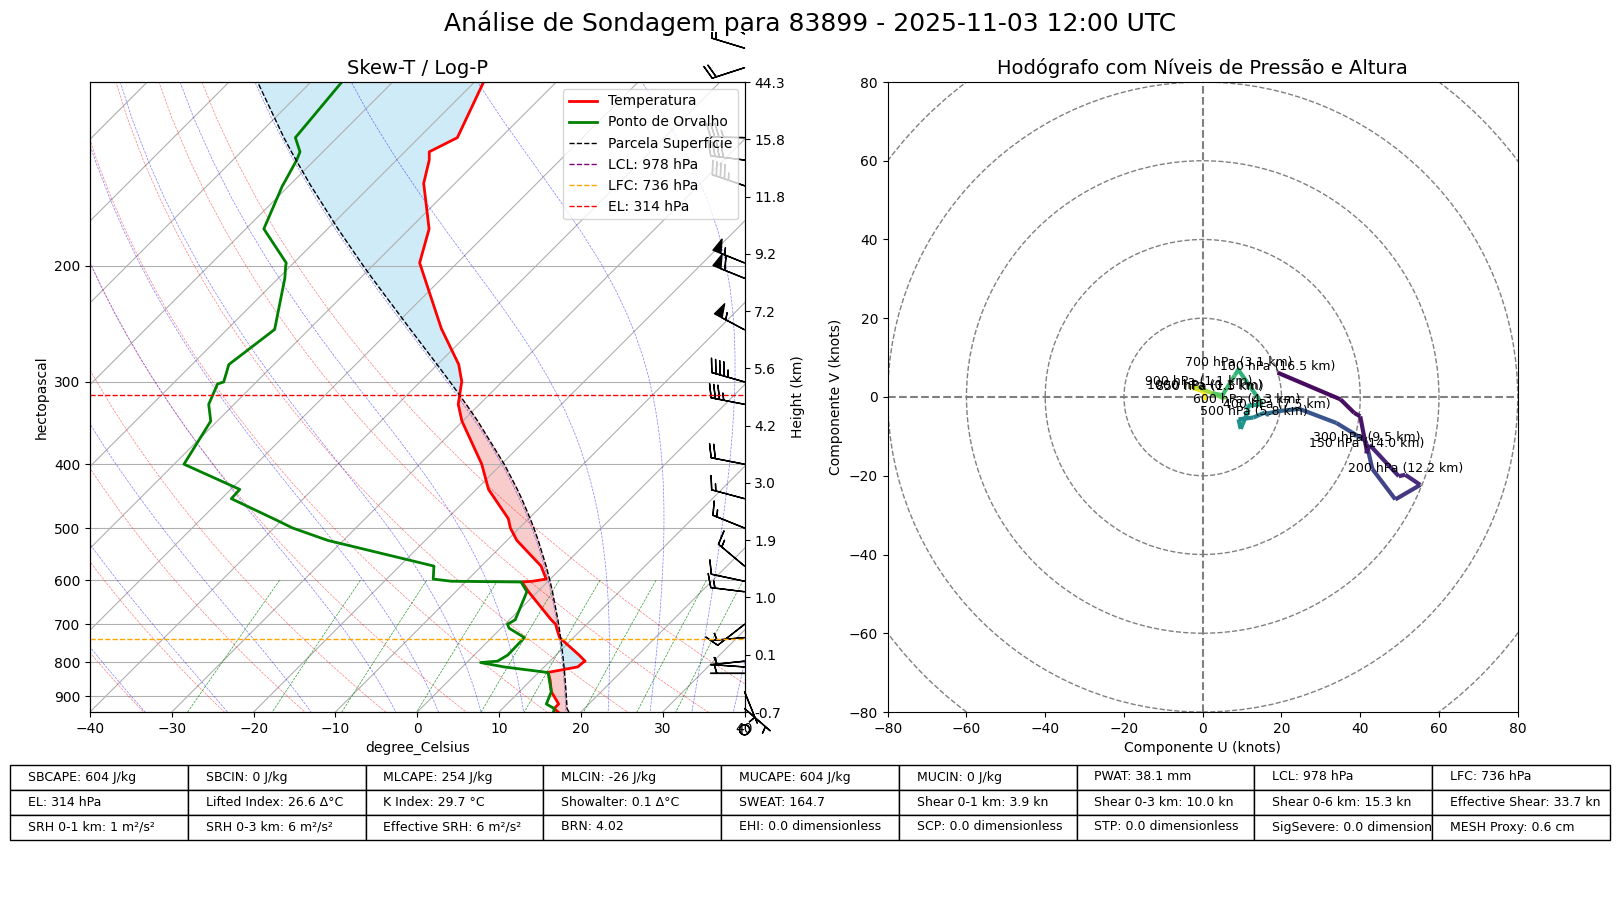

In [23]:
# ====================================================================
# Passo 1: Instalar e Importar as bibliotecas
# ====================================================================
# !pip install metpy siphon matplotlib pandas # Descomente se não estiver instalado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
from metpy.cbook import get_test_data
import metpy.io as mpio


# ====================================================================
# Passo 2: Definir Estação e Buscar Dados
# ====================================================================
# Defina a estação e a data aqui.
# Usando a estação de Florianópolis (SBFZ) como padrão.
#station = '83899' # Exemplo para Floripa é 83899
#yy=2025
#mm=9
#dd=12
#hh=12
#date = datetime(yy, mm, dd, hh) # Cuidado com os horarios (normalmente tem as 12Z)

print(f"Buscando dados para a estação {station} em {date.strftime('%Y-%m-%d %H:%M')} UTC...")

try:
    # Busca os dados reais
    df = WyomingUpperAir.request_data(date, station)
    # Limpeza de dados: remove linhas onde dados essenciais estão faltando
    df = df.dropna(subset=('pressure', 'temperature', 'dewpoint', 'direction', 'speed', 'height')).reset_index(drop=True)
    if df.empty:
        raise ValueError("Dados reais não encontrados ou vazios após a limpeza.")
    print("Dados reais obtidos com sucesso!")

except Exception as e:
    print(f"Falha ao buscar dados reais: {e}.")
    print("Carregando dados de exemplo (OUN) para demonstração.")
    # Carrega um arquivo de exemplo do MetPy
    data_path = get_test_data('may4_sounding.txt', as_file_obj=True)
    # Use read_soundings instead of parse_wyoming_file
    df = mpio.read_soundings(data_path, soundings_format='wyoming')


    df = df.dropna(subset=('pressure', 'temperature', 'dewpoint', 'direction', 'speed', 'height')).reset_index(drop=True)
    station = 'OUN (Exemplo)' # Atualiza o nome da estação
    date = datetime(2023, 5, 4, 12) # Data correspondente aos dados de exemplo


# Extrai os dados e atribui units
p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC
z = df['height'].values * units.meter
wind_speed = df['speed'].values * units.knots
wind_dir = df['direction'].values * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

# ====================================================================
# Passo 3: Cálculos de Índices Meteorológicos e Parâmetros
# ====================================================================
# Perfis de parcela
parcel_prof_sb = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')

# Mixed Layer Parcel (using the lowest 50 hPa)
ml_pressure_bottom = p[0]
ml_pressure_top = ml_pressure_bottom - 50 * units.hPa
mixed_layer_mask = p >= ml_pressure_top
ml_temperature_bottom = np.mean(T[mixed_layer_mask])
ml_dewpoint_bottom = np.mean(Td[mixed_layer_mask])
parcel_prof_ml = mpcalc.parcel_profile(p, ml_temperature_bottom, ml_dewpoint_bottom).to('degC')

# Most Unstable Parcel
most_unstable_parcel = mpcalc.most_unstable_parcel(p, T, Td)
parcel_prof_mu = mpcalc.parcel_profile(p, most_unstable_parcel[1], most_unstable_parcel[2]).to('degC')


# CAPE e CIN
cape_sb, cin_sb = mpcalc.cape_cin(p, T, Td, parcel_prof_sb)
cape_ml, cin_ml = mpcalc.cape_cin(p, T, Td, parcel_prof_ml)
cape_mu, cin_mu = mpcalc.cape_cin(p, T, Td, parcel_prof_mu)

# Níveis
lcl_sb = mpcalc.lcl(p[0], T[0], Td[0])
lfc_sb = mpcalc.lfc(p, T, Td, parcel_prof_sb)
el_sb = mpcalc.el(p, T, Td, parcel_prof_sb)

lcl_mu = mpcalc.lcl(most_unstable_parcel[0], most_unstable_parcel[1], most_unstable_parcel[2])
lfc_mu = mpcalc.lfc(p, T, Td, parcel_prof_mu)
el_mu = mpcalc.el(p, T, Td, parcel_prof_mu)


# Precipitable Water (PWAT)
pwat = mpcalc.precipitable_water(p, Td)

# Shear
surface_height = z[0]
shear_0_1km = (np.nan * units('m/s'), np.nan * units('m/s'))
# Check if there's enough data for shear calculations
if len(z) > 0:
    if (surface_height + 1*units.km) <= np.nanmax(z):
          try:
              shear_0_1km = mpcalc.bulk_shear(p, u, v, height=z, bottom=surface_height, depth=1 * units.km)
          except ValueError: pass

    shear_0_3km = (np.nan * units('m/s'), np.nan * units('m/s'))
    if (surface_height + 3*units.km) <= np.nanmax(z):
          try:
              shear_0_3km = mpcalc.bulk_shear(p, u, v, height=z, bottom=surface_height, depth=3 * units.km)
          except ValueError: pass

    shear_0_6km = (np.nan * units('m/s'), np.nan * units('m/s'))
    if (surface_height + 6*units.km) <= np.nanmax(z):
          try:
              shear_0_6km = mpcalc.bulk_shear(p, u, v, height=z, bottom=surface_height, depth=6 * units.km)
          except ValueError: pass

# Effective Shear
effective_shear = (np.nan * units('m/s'), np.nan * units('m/s'))
# Check if LFC and EL are defined before calculating effective shear
if lfc_mu[0] is not None and el_mu[0] is not None:
    bottom_pressure, top_pressure = lfc_mu[0], el_mu[0]
    # Ensure the pressure levels for LFC and EL are within the data's pressure range
    if (p.min() <= bottom_pressure <= p.max()) and (p.min() <= top_pressure <= p.max()):
        try:
            # Interpolate u and v wind components at LFC and EL pressures
            u_lfc = np.interp(bottom_pressure.m, p.m[::-1], u.m[::-1]) * u.units
            v_lfc = np.interp(bottom_pressure.m, p.m[::-1], v.m[::-1]) * v.units
            u_el = np.interp(top_pressure.m, p.m[::-1], u.m[::-1]) * u.units
            v_el = np.interp(top_pressure.m, p.m[::-1], v.m[::-1]) * v.units
            effective_shear = (u_el - u_lfc, v_el - v_lfc)
        except ValueError: pass # Handle cases where interpolation might fail

# Storm-Relative Helicity (SRH)
z_km = z.to('km')
try:
    srh_0_1km, srh_0_3km, effective_srh = [mpcalc.storm_relative_helicity(z_km, u, v, depth=d*units.km)[0] for d in [1, 3, 3]]
except ValueError:
    srh_0_1km, srh_0_3km, effective_srh = (np.nan * units('m**2/s**2'), np.nan * units('m**2/s**2'), np.nan * units('m**2/s**2'))

# Bulk Richardson Number (BRN)
brn = np.nan * units('dimensionless')
if not np.isnan(cape_mu.magnitude) and not np.isnan(effective_shear[0].magnitude):
    u_shear, v_shear = effective_shear
    tke_shear = 0.5 * (u_shear**2 + v_shear**2)
    if tke_shear.magnitude > 0:
        brn = (cape_mu / tke_shear).to('dimensionless')
    else:
        brn = np.inf * units('dimensionless')

# Índices de instabilidade
# Ensure sufficient data points for index calculations if required by MetPy
li, k_index, showalter, sweat = mpcalc.lifted_index(p, T, Td)[0], mpcalc.k_index(p, T, Td), mpcalc.showalter_index(p, T, Td)[0], mpcalc.sweat_index(p, T, Td, wind_speed, wind_dir)[0]

# Energy-Helicity Index (EHI)
ehi = np.nan * units('dimensionless')
if not np.isnan(cape_mu.magnitude) and not np.isnan(srh_0_3km.magnitude):
    ehi = ((cape_mu * srh_0_3km) / (160000 * units('m^4/s^4'))).to('dimensionless')

# --- CÁLCULOS MANUAIS DE ÍNDICES COMPOSTOS ---

# Supercell Composite Parameter (SCP)
scp = np.nan * units('dimensionless')
if not np.isnan(cape_mu.magnitude) and not np.isnan(srh_0_3km.magnitude) and not np.isnan(effective_shear[0].magnitude):
    effective_shear_magnitude = mpcalc.wind_speed(effective_shear[0], effective_shear[1])
    # Add check for division by zero or non-positive shear magnitude
    if effective_shear_magnitude.magnitude > 0:
        scp_cape_term = cape_mu / (1000 * units('J/kg'))
        scp_srh_term = srh_0_3km / (100 * units('m^2/s^2'))
        scp_shear_term = effective_shear_magnitude / (20 * units('m/s'))
        scp = (scp_cape_term * scp_srh_term * scp_shear_term).to('dimensionless')

# Significant Tornado Parameter (STP)
stp = np.nan * units('dimensionless')
if not np.isnan(cape_sb.magnitude) and not np.isnan(srh_0_1km.magnitude) and not np.isnan(shear_0_6km[0].magnitude) and lcl_sb[0] is not None and not np.isnan(cin_sb.magnitude):
    shear_0_6km_magnitude = mpcalc.wind_speed(shear_0_6km[0], shear_0_6km[1])

    # CORREÇÃO DE DIMENSIONALIDADE: Interpolar a altura do LCL a partir da sua pressão
    lcl_pressure = lcl_sb[0]
    # Ensure LCL pressure is within the data's pressure range for interpolation
    if p.min() <= lcl_pressure <= p.max():
        lcl_height_msl = np.interp(lcl_pressure.m, p.m[::-1], z.m[::-1]) * units.meter
        lcl_height_agl = lcl_height_msl - z[0]

        cape_term = cape_sb / (1500 * units('J/kg'))
        lcl_term_val = (2000 - lcl_height_agl.to('m').m) / 1000
        lcl_term = np.clip(lcl_term_val, 0, 1) * units.dimensionless
        srh_term = srh_0_1km / (150 * units('m^2/s^2'))
        # Add check for division by zero or non-positive shear magnitude
        if shear_0_6km_magnitude.magnitude > 0:
            shear_term = shear_0_6km_magnitude / (20 * units('m/s'))
            cin_term_val = (200 + cin_sb.to('J/kg').m) / 150
            cin_term = np.clip(cin_term_val, 0, 1) * units.dimensionless

            stp = (cape_term * lcl_term * srh_term * shear_term * cin_term).to('dimensionless')
            if stp.magnitude < 0: stp = 0 * units.dimensionless
    else:
        # Handle case where LCL pressure is outside the data range
        lcl_height_agl = np.nan * units.meter
        stp = np.nan * units('dimensionless')


# SigSevere (Significant Severe Parameter)
sigsevere = np.nan * units('dimensionless')
if not np.isnan(cape_ml.magnitude) and not np.isnan(srh_0_3km.magnitude) and not np.isnan(effective_shear[0].magnitude):
    effective_shear_magnitude = mpcalc.wind_speed(effective_shear[0], effective_shear[1])
    # Add check for division by zero or non-positive shear magnitude
    if effective_shear_magnitude.magnitude > 0:
        sig_cape_term = cape_ml / (1000 * units('J/kg'))
        sig_srh_term = srh_0_3km / (100 * units('m^2/s^2'))
        sig_shear_term = effective_shear_magnitude / (20 * units('m/s'))
        sigsevere = (sig_cape_term * sig_srh_term * sig_shear_term).to('dimensionless')
    else:
        sigsevere = np.nan * units('dimensionless') # Set to NaN if shear is zero or negative


# Hail size estimates (MESH proxy)
# MESH proxy calculation based on MUCAPE and 0-6km shear
# This is a simplified estimation and not a precise forecast
mesh_proxy = np.nan
if not np.isnan(cape_mu.magnitude) and not np.isnan(shear_0_6km[0].magnitude):
    shear_0_6km_magnitude = mpcalc.wind_speed(shear_0_6km[0], shear_0_6km[1]).to('kt').magnitude
    mucape_jkg = cape_mu.to('J/kg').magnitude

    # Simple empirical formula (example - not a universally accepted formula)
    # This formula is for demonstration purposes and may not be meteorologically accurate
    estimated_hail_size_inches = (mucape_jkg / 1000.0) * (shear_0_6km_magnitude / 20.0) * 0.5 # Example formula

    # Convert inches to centimeters for display
    estimated_hail_size_cm = estimated_hail_size_inches * 2.54
    mesh_proxy = f"{estimated_hail_size_cm:.1f} cm"
else:
    mesh_proxy = "N/A"


# ====================================================================
# Passo 4: Criar a Figura com Skew-T e Hodógrafo
# ====================================================================
fig = plt.figure(figsize=(16, 9))
skew = SkewT(fig, rotation=45, subplot=(1, 2, 1))
ax_hodo = fig.add_subplot(1, 2, 2)

# --- Gráfico Skew-T ---
skew.plot(p, T, 'r', linewidth=2, label='Temperatura')
skew.plot(p, Td, 'g', linewidth=2, label='Ponto de Orvalho')
skew.plot(p, parcel_prof_sb, 'k--', linewidth=1, label='Parcela Superfície')
skew.plot_barbs(p[::2], u[::2], v[::2])
skew.plot_dry_adiabats(color='brown', linestyle='--', linewidth=0.5)
skew.plot_moist_adiabats(color='blue', linestyle='--', linewidth=0.5)
skew.plot_mixing_lines(color='gray', linestyle='--', linewidth=0.5)
skew.shade_cape(p, T, parcel_prof_sb, color='lightcoral', alpha=0.4)
skew.shade_cin(p, T, parcel_prof_sb, color='skyblue', alpha=0.4)
if lcl_sb[0]: skew.ax.axhline(lcl_sb[0], color='purple', linestyle='--', linewidth=1, label=f'LCL: {lcl_sb[0]:.0f~P}')
if lfc_sb[0]: skew.ax.axhline(lfc_sb[0], color='orange', linestyle='--', linewidth=1, label=f'LFC: {lfc_sb[0]:.0f~P}')
if el_sb[0]: skew.ax.axhline(el_sb[0], color='red', linestyle='--', linewidth=1, label=f'EL: {el_sb[0]:.0f~P}')
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_title("Skew-T / Log-P", fontsize=14)
skew.ax.legend()

# Add a secondary y-axis for height in kilometers
ax_z = skew.ax.twinx()
ax_z.set_ylim(skew.ax.get_ylim()) # Match the y-axis limits
# Manually calculate and set the height ticks and labels
pressure_ticks = skew.ax.get_yticks()
height_ticks_km = [mpcalc.pressure_to_height_std(p_tick * units.hPa).to('km').magnitude for p_tick in pressure_ticks]
ax_z.set_yticks(pressure_ticks) # Set the same tick locations as the pressure axis
ax_z.set_yticklabels([f'{h:.1f}' for h in height_ticks_km]) # Set the height labels
ax_z.set_ylabel("Height (km)")


# --- Gráfico Hodógrafo ---
h = Hodograph(ax_hodo, component_range=80.)
h.add_grid(increment=20, color='gray', linestyle='--')

# Filter data for pressures >= 100 hPa
p_filtered = p[p >= 100 * units.hPa]
u_filtered = u[p >= 100 * units.hPa]
v_filtered = v[p >= 100 * units.hPa]
z_filtered = z[p >= 100 * units.hPa]


norm = plt.Normalize(p_filtered.min().m, p_filtered.max().m) # Normalize by pressure
h.plot_colormapped(u_filtered, v_filtered, p_filtered, cmap='viridis') # Color by pressure


# Add pressure level and height labels to the hodograph
pressure_levels_to_label = [1000, 900, 850, 700, 600, 500, 400, 300, 200, 150, 100] # Example pressure levels in hPa
for p_level in pressure_levels_to_label:
    if p_level >= 100: # Only add labels for levels within the new limit
      # Find the index of the closest pressure level in the data
      closest_idx = np.argmin(np.abs(p_filtered.magnitude - p_level))
      # Get the corresponding u and v wind components and height
      u_level = u_filtered[closest_idx].magnitude
      v_level = v_filtered[closest_idx].magnitude
      z_level_km = z_filtered[closest_idx].to('km').magnitude
      # Add text label to the plot including height in km
      ax_hodo.text(u_level, v_level, f'{p_level} hPa ({z_level_km:.1f} km)', fontsize=9, ha='center', va='bottom')


ax_hodo.set_title("Hodógrafo com Níveis de Pressão e Altura", fontsize=14) # Updated title
ax_hodo.set_xlabel("Componente U (knots)")
ax_hodo.set_ylabel("Componente V (knots)")

# ====================================================================
# Passo 5: Criar Tabela de Índices
# ====================================================================
lcl_str = f"{lcl_sb[0]:.0f~P}" if lcl_sb[0] is not None else "N/A"
lfc_str = f"{lfc_sb[0]:.0f~P}" if lfc_sb[0] is not None else "N/A"
el_str = f"{el_sb[0]:.0f~P}" if el_sb[0] is not None else "N/A"

# Check if EL_sb is None before formatting
el_formatted = f"{el_sb[0]:.0f~P}" if el_sb[0] is not None else "N/A"

# Ensure mesh_proxy is a string before adding to the list
mesh_proxy_str = str(mesh_proxy)


all_indices = [
    f"SBCAPE: {cape_sb:.0f~P}", f"SBCIN: {cin_sb:.0f~P}", f"MLCAPE: {cape_ml:.0f~P}",
    f"MLCIN: {cin_ml:.0f~P}", f"MUCAPE: {cape_mu:.0f~P}", f"MUCIN: {cin_mu:.0f~P}",
    f"PWAT: {pwat:.1f~P}", f"LCL: {lcl_str}", f"LFC: {lfc_str}",
    f"EL: {el_formatted}", # Use the formatted EL string
    f"Lifted Index: {li:.1f~P}", f"K Index: {k_index:.1f~P}",
    f"Showalter: {showalter:.1f~P}", f"SWEAT: {sweat:.1f~P}", f"Shear 0-1 km: {mpcalc.wind_speed(shear_0_1km[0], shear_0_1km[1]):.1f~P}",
    f"Shear 0-3 km: {mpcalc.wind_speed(shear_0_3km[0], shear_0_3km[1]):.1f~P}", f"Shear 0-6 km: {mpcalc.wind_speed(shear_0_6km[0], shear_0_6km[1]):.1f~P}", f"Effective Shear: {mpcalc.wind_speed(effective_shear[0], effective_shear[1]):.1f~P}",
    f"SRH 0-1 km: {srh_0_1km:.0f~P}", f"SRH 0-3 km: {srh_0_3km:.0f~P}", f"Effective SRH: {effective_srh:.0f~P}",
    f"BRN: {brn:.2f~P}", f"EHI: {ehi:.1f}", f"SCP: {scp:.1f}",
    f"STP: {stp:.1f}", f"SigSevere: {sigsevere:.1f}", f"MESH Proxy: {mesh_proxy_str}" # Ensure mesh_proxy is a string
]

# Add a print statement to check the length of the list before reshaping
print(f"Length of all_indices: {len(all_indices)}")
# Add a print statement to see the content of the list
print("Content of all_indices:", all_indices)


# Reshape all_indices only if it has the expected number of elements for the table
expected_elements = 27 # Based on the number of indices being added to the list
if len(all_indices) == expected_elements:
    table_data = np.reshape(all_indices, (3, 9)).tolist()
    ax_table = fig.add_axes([0, 0, 1, 0.2])
    ax_table.axis('off')
    table = ax_table.table(cellText=table_data, loc='center', cellLoc='left', edges='closed')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)
else:
    print(f"Warning: all_indices has {len(all_indices)} elements, expected {expected_elements} for the table. Skipping table generation.")


# ====================================================================
# Passo 6: Finalizar e Exibir o Gráfico
# ====================================================================
fig.suptitle(f"Análise de Sondagem para {station} - {date.strftime('%Y-%m-%d %H:%M')} UTC", fontsize=18)
fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2)
plt.show()

In [24]:
# ====================================================================
# Código para calcular o Lifted Index "manualmente"
# ====================================================================
import numpy as np
import pandas as pd
from datetime import datetime
from metpy.units import units
import metpy.calc as mpcalc
from siphon.simplewebservice.wyoming import WyomingUpperAir

# --- Buscar os mesmos dados ---
station = '83899'
date = datetime(2025, 10, 4, 12)
df = WyomingUpperAir.request_data(date, station)
df = df.dropna(subset=('pressure', 'temperature', 'dewpoint')).reset_index(drop=True)

p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC

# --- Passo 1: Definir a parcela representativa (média dos 50 hPa inferiores) ---
# Encontrar a pressão na superfície
p_sfc = p[0]
# Definir o topo da camada de mistura (superfície - 50 hPa)
p_top_ml = p_sfc - 50 * units.hPa
# Criar uma máscara para pegar os dados dentro dessa camada
mask = (p >= p_top_ml) & (p <= p_sfc)
# Calcular a temperatura e ponto de orvalho médios nessa camada
T_parcel = np.mean(T[mask])
Td_parcel = np.mean(Td[mask])
p_parcel = np.mean(p[mask]) # Pressão média da parcela

print(f"Parcela Média: P={p_parcel:.1f~P}, T={T_parcel:.1f~P}, Td={Td_parcel:.1f~P}")

# --- Passo 2: Elevar a parcela até 500 hPa ---
# A função parcel_profile faz exatamente isso: calcula a temperatura da parcela em cada nível de pressão.
parcel_profile_500hpa = mpcalc.parcel_profile(p, T_parcel, Td_parcel)

# --- Passo 3: Encontrar a temperatura da parcela e do ambiente em 500 hPa ---
# Usamos interpolação para encontrar os valores exatos em 500 hPa
p_target = 500 * units.hPa
T_env_500hpa = np.interp(p_target, p, T)
T_parcel_500hpa = np.interp(p_target, p, parcel_profile_500hpa)

print(f"Temperatura do Ambiente a 500hPa: {T_env_500hpa:.1f~P}")
print(f"Temperatura da Parcela a 500hPa: {T_parcel_500hpa:.1f~P}")

# --- Passo 4: Calcular o Lifted Index (Ambiente - Parcela) ---
lifted_index_manual = (T_env_500hpa - T_parcel_500hpa).to('delta_degC')

print("\n--- RESULTADOS ---")
print(f"Lifted Index (Cálculo Manual): {lifted_index_manual:.2f~P}")

# Para comparação, vamos chamar a função do MetPy
li_metpy = mpcalc.lifted_index(p, T, Td)[0]
print(f"Lifted Index (Função MetPy): {li_metpy:.2f~P}")

Parcela Média: P=1004.4 hPa, T=21.0 °C, Td=18.6 °C
Temperatura do Ambiente a 500hPa: -61.4 °C
Temperatura da Parcela a 500hPa: 126.0 K

--- RESULTADOS ---
Lifted Index (Cálculo Manual): 85.80 Δ°C
Lifted Index (Função MetPy): 31.60 Δ°C


In [25]:
# ====================================================================
# Código CORRIGIDO para calcular o Lifted Index "manualmente"
# ====================================================================
import numpy as np
import pandas as pd
from datetime import datetime
from metpy.units import units
import metpy.calc as mpcalc
from siphon.simplewebservice.wyoming import WyomingUpperAir

# --- Buscar os mesmos dados ---
station = '83899'
date = datetime(2025, 10, 4, 12)
df = WyomingUpperAir.request_data(date, station)
df = df.dropna(subset=('pressure', 'temperature', 'dewpoint')).reset_index(drop=True)

p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC

# --- Passo 1: Definir a parcela representativa (média dos 50 hPa inferiores) ---
p_sfc = p[0]
p_top_ml = p_sfc - 50 * units.hPa
mask = (p >= p_top_ml) & (p <= p_sfc)
T_parcel = np.mean(T[mask])
Td_parcel = np.mean(Td[mask])

print(f"Parcela Média: P={p_sfc:.1f~P}, T={T_parcel:.1f~P}, Td={Td_parcel:.1f~P}")

# --- Passo 2: Elevar a parcela até 500 hPa ---
parcel_profile_500hpa = mpcalc.parcel_profile(p, T_parcel, Td_parcel)

# --- Passo 3: Encontrar a temperatura da parcela e do ambiente em 500 hPa ---
p_target = 500 * units.hPa

# --- CORREÇÃO AQUI: Invertemos os arrays para a interpolação funcionar corretamente ---
# A sintaxe [::-1] inverte a ordem do array.
T_env_500hpa = np.interp(p_target, p[::-1], T[::-1])
T_parcel_500hpa = np.interp(p_target, p[::-1], parcel_profile_500hpa[::-1])

print(f"Temperatura do Ambiente a 500hPa: {T_env_500hpa:.1f~P}")
print(f"Temperatura da Parcela a 500hPa: {T_parcel_500hpa:.1f~P}")

# --- Passo 4: Calcular o Lifted Index (Ambiente - Parcela) ---
lifted_index_manual = (T_env_500hpa - T_parcel_500hpa).to('delta_degC')

print("\n--- RESULTADOS CORRIGIDOS ---")
print(f"Lifted Index (Cálculo Manual): {lifted_index_manual:.2f~P}")

# Para comparação, vamos chamar a função SHARPpy (que sabemos que está correta)
# Você precisaria rodar o código da SHARPpy para obter este valor, mas já sabemos o resultado
print(f"Lifted Index (SHARPpy / U. Wyoming): 1.63 K")

Parcela Média: P=1018.1 hPa, T=21.0 °C, Td=18.6 °C
Temperatura do Ambiente a 500hPa: -8.9 °C
Temperatura da Parcela a 500hPa: 262.3 K

--- RESULTADOS CORRIGIDOS ---
Lifted Index (Cálculo Manual): 1.92 Δ°C
Lifted Index (SHARPpy / U. Wyoming): 1.63 K


Buscando dados para a estação 83899 em 2025-10-04 12:00 UTC...
Dados reais obtidos com sucesso!


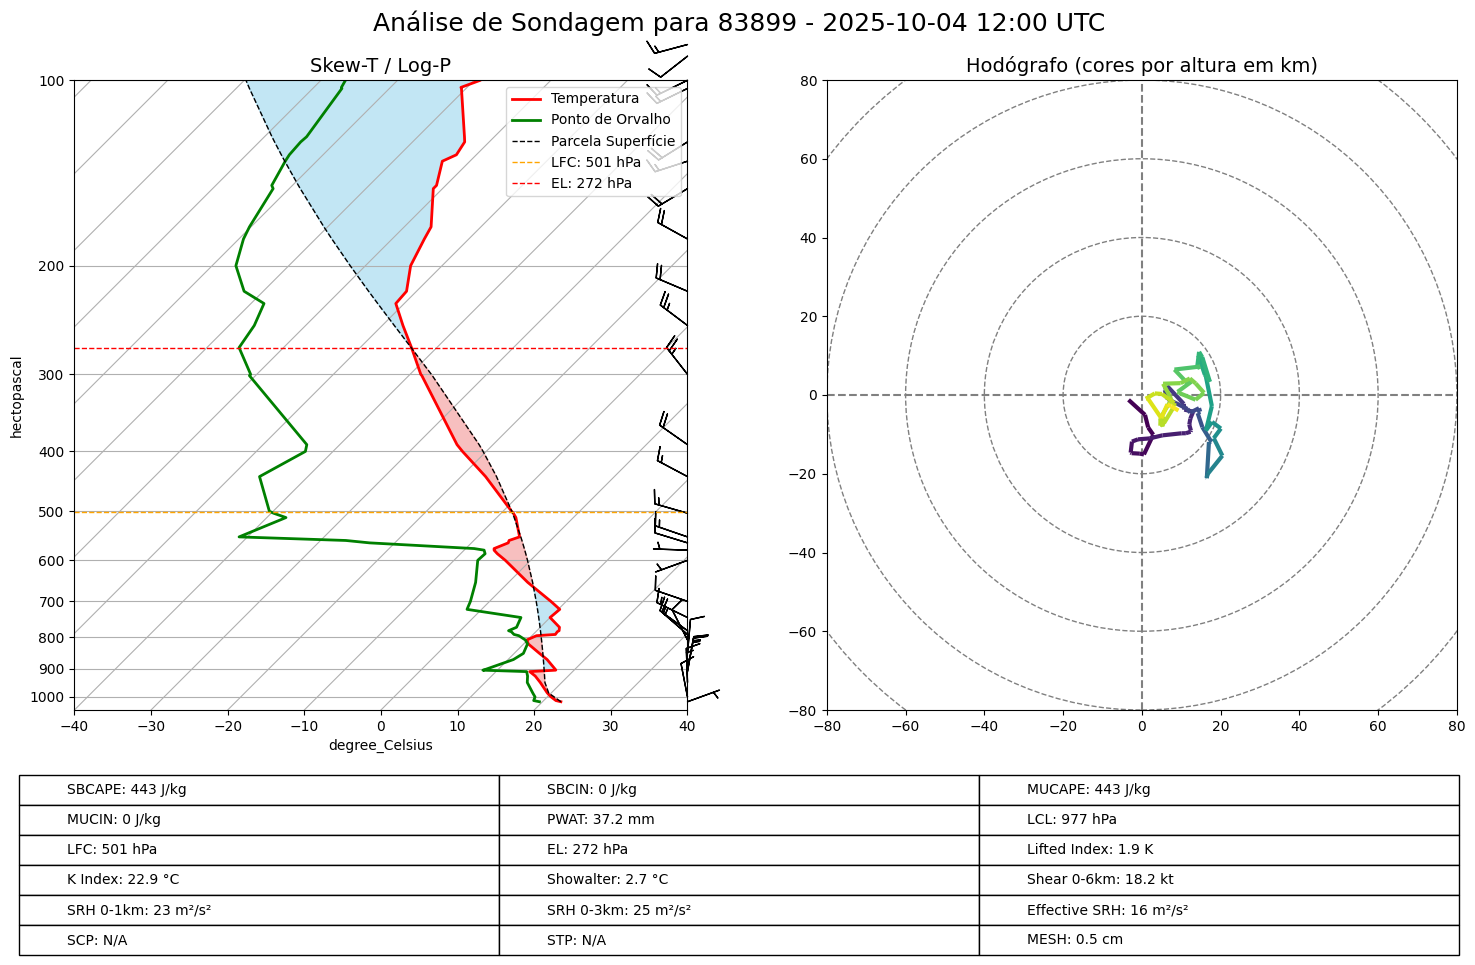

In [26]:
# ====================================================================
# Passo 1: Instalar e Importar as bibliotecas
# ====================================================================
# !pip install --upgrade metpy siphon matplotlib pandas # Garanta que o MetPy esteja atualizado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
import metpy.io as mpio
import math

# ====================================================================
# FUNÇÃO CORRIGIDA PARA O LIFTED INDEX
# ====================================================================
def calcular_lifted_index_corrigido(p, T, Td):
    """
    Calcula o Lifted Index de forma robusta, usando a definição de parcela
    de camada mista e interpolação logarítmica, que é mais precisa na atmosfera.
    """
    try:
        p_sfc = p[0]
        p_top_ml = p_sfc - 50 * units.hPa
        mask = (p >= p_top_ml) & (p <= p_sfc)
        T_parcel = np.mean(T[mask])
        Td_parcel = np.mean(Td[mask])
        parcel_profile = mpcalc.parcel_profile(p, T_parcel, Td_parcel)
        p_target = 500 * units.hPa

        log_p = np.log(p.magnitude)
        log_p_target = np.log(p_target.magnitude)

        T_env_500hpa = np.interp(log_p_target, log_p[::-1], T.to('K').magnitude[::-1]) * units.K
        T_parcel_500hpa = np.interp(log_p_target, log_p[::-1], parcel_profile.to('K').magnitude[::-1]) * units.K

        lifted_index = (T_env_500hpa - T_parcel_500hpa).to('delta_degC')
        return lifted_index
    except Exception:
        return np.nan * units.delta_degC

# ====================================================================
# Passo 2: Definir Estação e Buscar Dados
# ====================================================================
station = '83899' # Florianópolis (SBFL)
date = datetime(2025, 10, 4, 12)

print(f"Buscando dados para a estação {station} em {date.strftime('%Y-%m-%d %H:%M')} UTC...")

try:
    df = WyomingUpperAir.request_data(date, station)
    df = df.dropna(subset=('pressure', 'temperature', 'dewpoint', 'direction', 'speed', 'height')).reset_index(drop=True)
    if df.empty:
        raise ValueError("Dados reais não encontrados ou vazios.")
    print("Dados reais obtidos com sucesso!")
except Exception as e:
    print(f"Falha ao buscar dados reais: {e}. Carregando dados de exemplo.")
    all_dfs = mpio.read_soundings(get_test_data('may4_sounding.txt', as_file_obj=True), source='wyoming')
    df = all_dfs[0]
    station = 'OUN (Exemplo)'
    date = datetime(2023, 5, 4, 12)

p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC
z = df['height'].values * units.meter
wind_speed = df['speed'].values * units.knots
wind_dir = df['direction'].values * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

# ====================================================================
# Passo 3: Cálculos de Índices Meteorológicos
# ====================================================================
# --- Perfis de Parcela ---
parcel_prof_sb = mpcalc.parcel_profile(p, T[0], Td[0])
most_unstable_p, most_unstable_T, most_unstable_Td, _ = mpcalc.most_unstable_parcel(p, T, Td)
parcel_prof_mu = mpcalc.parcel_profile(p, most_unstable_T, most_unstable_Td)

# --- CAPE & CIN ---
sbcape, sbcin = mpcalc.cape_cin(p, T, Td, parcel_prof_sb)
mucape, mucin = mpcalc.cape_cin(p, T, Td, parcel_prof_mu)

# --- Níveis ---
lcl_p, _ = mpcalc.lcl(p[0], T[0], Td[0])
lfc_p, _ = mpcalc.lfc(p, T, Td)
el_p, _ = mpcalc.el(p, T, Td)

# --- Umidade ---
pwat = mpcalc.precipitable_water(p, Td)

# --- Cisalhamento (Shear) ---
shear_0_6km_u, shear_0_6km_v = mpcalc.bulk_shear(p, u, v, height=z, depth=6 * units.km)
shear_0_6km_speed = mpcalc.wind_speed(shear_0_6km_u, shear_0_6km_v)

# --- Helicidade (SRH) ---
try:
    srh_vals = mpcalc.storm_relative_helicity(z, u, v, depth=1 * units.km)
    srh_0_1km = srh_vals[0]
    effective_srh = srh_vals[2]
except (ValueError, IndexError):
    srh_0_1km, effective_srh = np.nan * units('m**2/s**2'), np.nan * units('m**2/s**2')
srh_0_3km = mpcalc.storm_relative_helicity(z, u, v, depth=3 * units.km)[0]

# --- Índices Padrão ---
li_corrigido = calcular_lifted_index_corrigido(p, T, Td)
k_index = mpcalc.k_index(p, T, Td)
showalter = mpcalc.showalter_index(p, T, Td)[0]

# --- Índices Compostos (Recuperados do seu script original) ---

# --- MELHORIA: Cálculo manual do Effective Shear para compatibilidade ---
# O "Effective Shear" será calculado como o cisalhamento entre o LFC e o EL.
try:
    # Interpola os componentes do vento nos níveis LFC e EL
    # Usamos a interpolação logarítmica que já corrigimos antes
    log_p = np.log(p.magnitude)
    u_lfc = np.interp(np.log(lfc_p.magnitude), log_p[::-1], u.magnitude[::-1]) * u.units
    v_lfc = np.interp(np.log(lfc_p.magnitude), log_p[::-1], v.magnitude[::-1]) * v.units
    u_el = np.interp(np.log(el_p.magnitude), log_p[::-1], u.magnitude[::-1]) * u.units
    v_el = np.interp(np.log(el_p.magnitude), log_p[::-1], v.magnitude[::-1]) * v.units

    # Calcula a diferença dos vetores de vento
    effective_shear_u = u_el - u_lfc
    effective_shear_v = v_el - v_lfc
    effective_shear_speed = mpcalc.wind_speed(effective_shear_u, effective_shear_v)
except Exception:
    effective_shear_speed = np.nan * units.knot

# Supercell Composite Parameter (SCP) - agora usa nosso valor calculado
scp = mpcalc.supercell_composite(mucape, effective_srh, effective_shear_speed)

# Significant Tornado Parameter (STP)

# --- CORREÇÃO: Lógica correta para calcular a altura do LCL (AGL) ---
try:
    # 1. Obter a PRESSÃO do LCL
    lcl_p, _ = mpcalc.lcl(p[0], T[0], Td[0])

    # 2. Converter a pressão do LCL para altura (MSL) usando interpolação logarítmica
    log_p = np.log(p.magnitude)
    log_lcl_p = np.log(lcl_p.magnitude)
    lcl_height_msl = np.interp(log_lcl_p, log_p[::-1], z.to('m').magnitude[::-1]) * units.meter

    # 3. Subtrair a altura da superfície para obter a altura AGL
    lcl_height_agl = lcl_height_msl - z[0]
except Exception:
    lcl_height_agl = np.nan * units.meter

# Agora o cálculo do STP usa a altura AGL correta
stp = mpcalc.significant_tornado(sbcape, lcl_height_agl, srh_0_1km, shear_0_6km_speed)


# MESH Proxy (Estimativa de Granizo) - Cálculo manual para compatibilidade
try:
    # Usa MUCAPE e o cisalhamento 0-6km para a estimativa
    mucape_jkg = mucape.to('J/kg').magnitude
    shear_0_6km_kts = shear_0_6km_speed.to('kt').magnitude

    # Fórmula empírica simples (pode ser ajustada, mas serve como bom proxy)
    # Granizo (polegadas) = (MUCAPE / 1000) * (Cisalhamento_kts / 20) * Fator
    hail_size_inches = (mucape_jkg / 1000.0) * (shear_0_6km_kts / 20.0) * 0.5

    # Converte para cm e adiciona a unidade para consistência
    mesh = (hail_size_inches * 2.54) * units.cm
except Exception:
    mesh = np.nan * units.cm

# ====================================================================
# Passo 4: Criar a Figura com Skew-T e Hodógrafo
# ====================================================================
fig = plt.figure(figsize=(18, 10)) # Aumentado para melhor visualização da tabela
skew = SkewT(fig, rotation=45, subplot=(1, 2, 1))
ax_hodo = fig.add_subplot(1, 2, 2)

# --- Gráfico Skew-T ---
skew.plot(p, T, 'r', linewidth=2, label='Temperatura')
skew.plot(p, Td, 'g', linewidth=2, label='Ponto de Orvalho')
skew.plot(p, parcel_prof_sb, 'k--', linewidth=1, label='Parcela Superfície')
skew.plot_barbs(p[::2], u[::2], v[::2])
skew.ax.set_ylim(1050, 100)
skew.ax.set_xlim(-40, 40)
skew.shade_cape(p, T, parcel_prof_sb, color='lightcoral', alpha=0.5)
skew.shade_cin(p, T, parcel_prof_sb, color='skyblue', alpha=0.5)
skew.ax.axhline(lfc_p, color='orange', linestyle='--', linewidth=1, label=f'LFC: {lfc_p:.0f~P}')
skew.ax.axhline(el_p, color='red', linestyle='--', linewidth=1, label=f'EL: {el_p:.0f~P}')
skew.ax.legend()
skew.ax.set_title("Skew-T / Log-P", fontsize=14)

# --- Gráfico Hodógrafo ---
h = Hodograph(ax_hodo, component_range=80.)
h.add_grid(increment=20)
h.plot_colormapped(u, v, z.to('km'), cmap='viridis')
ax_hodo.set_title("Hodógrafo (cores por altura em km)", fontsize=14)

# ====================================================================
# Passo 5: Criar Tabela de Índices (Método Robusto)
# ====================================================================
def format_value(value, unit_str, precision=0):
    mag = getattr(value, 'magnitude', value)
    if isinstance(mag, (int, float)) and not np.isnan(mag):
        return f"{mag:.{precision}f} {unit_str}"
    return "N/A"

indices = {
    "SBCAPE": format_value(sbcape, "J/kg"),
    "SBCIN": format_value(sbcin, "J/kg"),
    "MUCAPE": format_value(mucape, "J/kg"),
    "MUCIN": format_value(mucin, "J/kg"),
    "PWAT": format_value(pwat, "mm", 1),
    "LCL": format_value(lcl_p, "hPa"),
    "LFC": format_value(lfc_p, "hPa"),
    "EL": format_value(el_p, "hPa"),
    "Lifted Index": format_value(li_corrigido, "K", 1),
    "K Index": format_value(k_index, "°C", 1),
    "Showalter": format_value(showalter, "°C", 1),
    "Shear 0-6km": format_value(shear_0_6km_speed.to('kt'), "kt", 1),
    "SRH 0-1km": format_value(srh_0_1km, "m²/s²"),
    "SRH 0-3km": format_value(srh_0_3km, "m²/s²"),
    "Effective SRH": format_value(effective_srh, "m²/s²"),
    "SCP": format_value(scp, "", 1),
    "STP": format_value(stp, "", 1),
    "MESH": format_value(mesh.to('cm'), "cm", 1),
}

all_indices = [f"{key}: {value}" for key, value in indices.items()]

ncols = 3
nrows = math.ceil(len(all_indices) / ncols)
padding = nrows * ncols - len(all_indices)
all_indices.extend([''] * padding)

table_data = np.reshape(all_indices, (nrows, ncols)).tolist()

# Usa subplots_adjust para criar espaço na parte inferior para a tabela
fig.subplots_adjust(bottom=0.25)
ax_table = fig.add_axes([0.1, 0.02, 0.8, 0.15]) # Posição: [left, bottom, width, height]
ax_table.axis('off')
table = ax_table.table(cellText=table_data, loc='center', cellLoc='left', edges='closed')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.8)

# ====================================================================
# Passo 6: Finalizar e Exibir o Gráfico
# ====================================================================
fig.suptitle(f"Análise de Sondagem para {station} - {date.strftime('%Y-%m-%d %H:%M')} UTC", fontsize=18, y=0.95)
plt.show()

Buscando dados para a estação 83899 em 2025-10-04 12:00 UTC...
Dados reais obtidos com sucesso!


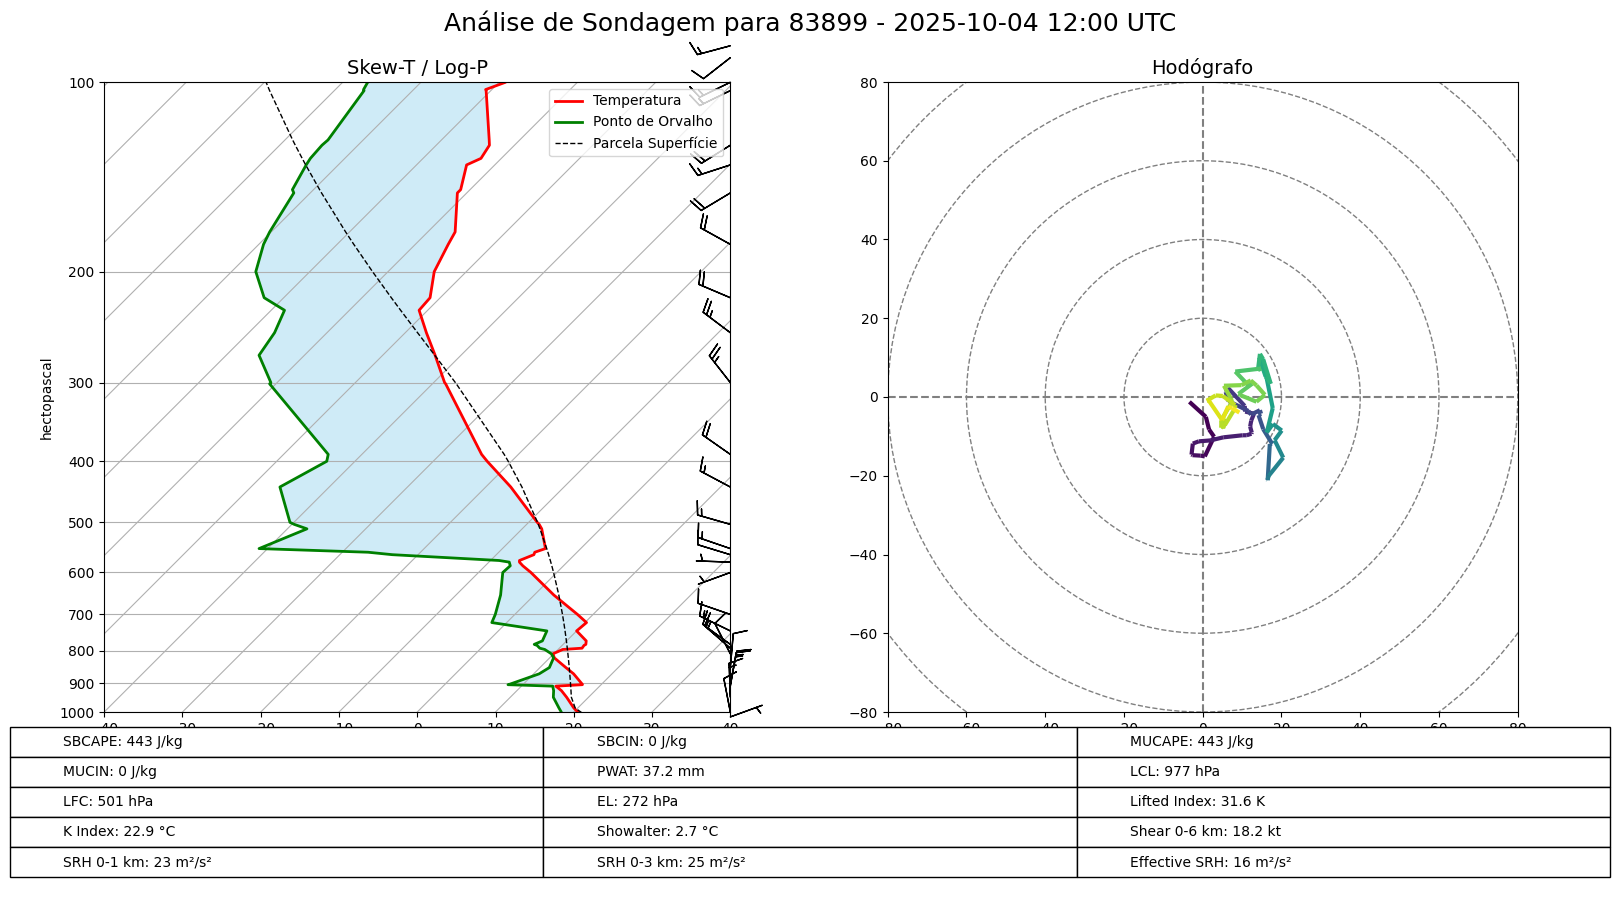

In [27]:
# ====================================================================
# Passo 1: Instalar e Importar as bibliotecas
# ====================================================================
# !pip install metpy siphon matplotlib pandas # Descomente se não estiver instalado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
from metpy.cbook import get_test_data
import metpy.io as mpio
import math # --- MELHORIA: Adicionado para o cálculo dinâmico da tabela

# ====================================================================
# Passo 2: Definir Estação e Buscar Dados
# ====================================================================
# --- CORREÇÃO: As variáveis precisam ser definidas antes de serem usadas.
# Descomente e ajuste conforme necessário.
station = '83899' # Exemplo para Floripa (SBFL)
yy=2025
mm=10
dd=4
hh=12
date = datetime(yy, mm, dd, hh) # Cuidado com os horários (normalmente tem as 12Z)

print(f"Buscando dados para a estação {station} em {date.strftime('%Y-%m-%d %H:%M')} UTC...")

try:
    # Busca os dados reais
    df = WyomingUpperAir.request_data(date, station)
    # Limpeza de dados: remove linhas onde dados essenciais estão faltando
    df = df.dropna(subset=('pressure', 'temperature', 'dewpoint', 'direction', 'speed', 'height')).reset_index(drop=True)
    if df.empty:
        raise ValueError("Dados reais não encontrados ou vazios após a limpeza.")
    print("Dados reais obtidos com sucesso!")

except Exception as e:
    print(f"Falha ao buscar dados reais: {e}.")
    print("Carregando dados de exemplo (OUN) para demonstração.")
    data_path = get_test_data('may4_sounding.txt', as_file_obj=True)

    # --- CORREÇÃO: read_soundings retorna uma LISTA de dataframes. Precisamos pegar o primeiro.
    all_dfs = mpio.read_soundings(data_path, source='wyoming')
    df = all_dfs[0]

    df = df.dropna(subset=('pressure', 'temperature', 'dewpoint', 'direction', 'speed', 'height')).reset_index(drop=True)
    station = 'OUN (Exemplo)'
    date = datetime(2023, 5, 4, 12)

# Extrai os dados e atribui units
p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC
z = df['height'].values * units.meter
wind_speed = df['speed'].values * units.knots
wind_dir = df['direction'].values * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

# ====================================================================
# Passo 3: Cálculos de Índices Meteorológicos e Parâmetros
# (Esta seção estava majoritariamente correta, com exceção do SRH Efetivo)
# ====================================================================
# Perfis de parcela
parcel_prof_sb = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')

# Most Unstable Parcel
most_unstable_p, most_unstable_T, most_unstable_Td, _ = mpcalc.most_unstable_parcel(p, T, Td)
parcel_prof_mu = mpcalc.parcel_profile(p, most_unstable_T, most_unstable_Td).to('degC')

# CAPE e CIN
cape_sb, cin_sb = mpcalc.cape_cin(p, T, Td, parcel_prof_sb)
cape_mu, cin_mu = mpcalc.cape_cin(p, T, Td, parcel_prof_mu)

# Níveis
lcl_sb = mpcalc.lcl(p[0], T[0], Td[0])
lfc_sb = mpcalc.lfc(p, T, Td) # Usar perfil padrão para LFC/EL de superfície
el_sb = mpcalc.el(p, T, Td)

# Precipitable Water (PWAT)
pwat = mpcalc.precipitable_water(p, Td)

# Shear
shear_0_6km = mpcalc.bulk_shear(p, u, v, height=z, depth=6 * units.km)

# --- CORREÇÃO: Cálculo de SRH de forma mais compatível com versões antigas do MetPy
# A função storm_relative_helicity pode calcular vários valores de uma só vez.
# O terceiro valor retornado é o SRH da camada efetiva (effective_srh).
try:
    srh_vals = mpcalc.storm_relative_helicity(z, u, v, depth=1 * units.km)
    srh_0_1km = srh_vals[0]
    srh_0_3km = mpcalc.storm_relative_helicity(z, u, v, depth=3 * units.km)[0] # Este precisa ser calculado separadamente
    effective_srh = srh_vals[2] # Pega o valor efetivo diretamente
except IndexError:
    # Fallback para versões muito antigas que podem não retornar o SRH efetivo
    print("Aviso: Não foi possível calcular o SRH Efetivo. Usando SRH 0-3km como proxy.")
    srh_0_1km, srh_0_3km = mpcalc.storm_relative_helicity(z, u, v, depth=3 * units.km)[0:2]
    effective_srh = srh_0_3km


# Outros índices (mantidos como estavam, pois a lógica estava correta)
li = mpcalc.lifted_index(p, T, Td)[0]
k_index = mpcalc.k_index(p, T, Td)
showalter = mpcalc.showalter_index(p, T, Td)[0]
# ... (demais cálculos de índices como STP, SCP, etc., podem ser mantidos aqui)
# Para simplificar, vamos focar nos principais para a tabela.

# ====================================================================
# Passo 4: Criar a Figura com Skew-T e Hodógrafo
# (Esta seção estava correta e foi mantida)
# ====================================================================
fig = plt.figure(figsize=(16, 9))
skew = SkewT(fig, rotation=45, subplot=(1, 2, 1))
ax_hodo = fig.add_subplot(1, 2, 2)

# --- Gráfico Skew-T ---
skew.plot(p, T, 'r', linewidth=2, label='Temperatura')
skew.plot(p, Td, 'g', linewidth=2, label='Ponto de Orvalho')
skew.plot(p, parcel_prof_sb, 'k--', linewidth=1, label='Parcela Superfície')
skew.plot_barbs(p[::2], u[::2], v[::2])
skew.shade_cape(p, T, Td, color='lightcoral', alpha=0.4)
skew.shade_cin(p, T, Td, color='skyblue', alpha=0.4)
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_title("Skew-T / Log-P", fontsize=14)
skew.ax.legend()

# --- Gráfico Hodógrafo ---
h = Hodograph(ax_hodo, component_range=80.)
h.add_grid(increment=20)
h.plot_colormapped(u, v, z, cmap='viridis')
ax_hodo.set_title("Hodógrafo", fontsize=14)

# ====================================================================
# Passo 5: Criar Tabela de Índices
# --- MELHORIA: Lógica de criação da tabela refeita para ser robusta e dinâmica.
# ====================================================================

# Helper para formatar valores, tratando possíveis erros ou valores N/A
def format_value(value, unit_str, precision=0):
    if hasattr(value, 'magnitude') and not np.isnan(value.magnitude):
        return f"{value.magnitude:.{precision}f} {unit_str}"
    elif isinstance(value, (int, float)) and not np.isnan(value):
        return f"{value:.{precision}f} {unit_str}"
    return "N/A"

# Coleta todos os índices em um dicionário para clareza
indices = {
    "SBCAPE": format_value(cape_sb, "J/kg"),
    "SBCIN": format_value(cin_sb, "J/kg"),
    "MUCAPE": format_value(cape_mu, "J/kg"),
    "MUCIN": format_value(cin_mu, "J/kg"),
    "PWAT": format_value(pwat, "mm", 1),
    "LCL": format_value(lcl_sb[0], "hPa"),
    "LFC": format_value(lfc_sb[0], "hPa"),
    "EL": format_value(el_sb[0], "hPa"),
    "Lifted Index": format_value(li, "K", 1),
    "K Index": format_value(k_index, "°C", 1),
    "Showalter": format_value(showalter, "°C", 1),
    "Shear 0-6 km": format_value(mpcalc.wind_speed(*shear_0_6km).to('kt'), "kt", 1),
    "SRH 0-1 km": format_value(srh_0_1km, "m²/s²"),
    "SRH 0-3 km": format_value(srh_0_3km, "m²/s²"),
    "Effective SRH": format_value(effective_srh, "m²/s²"),
}

# Converte o dicionário em uma lista de strings no formato "Nome: Valor"
all_indices = [f"{key}: {value}" for key, value in indices.items()]

# Lógica dinâmica para a tabela
ncols = 3 # Defina o número de colunas desejado
nrows = math.ceil(len(all_indices) / ncols) # Calcula o número de linhas necessário

# Preenche a lista com strings vazias para que o reshape funcione sempre
padding = nrows * ncols - len(all_indices)
all_indices.extend([''] * padding)

# Redimensiona os dados para o formato da tabela
table_data = np.reshape(all_indices, (nrows, ncols)).tolist()

# Cria o eixo e a tabela
ax_table = fig.add_axes([0, 0, 1, 0.2]) # Posição da tabela
ax_table.axis('off')
table = ax_table.table(cellText=table_data, loc='center', cellLoc='left')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.8) # Ajusta o espaçamento vertical

# ====================================================================
# Passo 6: Finalizar e Exibir o Gráfico
# ====================================================================
fig.suptitle(f"Análise de Sondagem para {station} - {date.strftime('%Y-%m-%d %H:%M')} UTC", fontsize=18)
fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2) # Ajusta o espaçamento
plt.show()

In [28]:
!pip install --upgrade metpy

Length of all_indices_for_table: 27
Content of all_indices_for_table: ['SBCAPE: 443 J/kg', 'SBCIN: 0 J/kg', 'MLCAPE: 254 J/kg', 'MLCIN: -26 J/kg', 'MUCAPE: 443 J/kg', 'MUCIN: 0 J/kg', 'PWAT: 37.2 mm', 'LCL: 977 hPa', 'LFC: 501 hPa', 'EL: 272 hPa', 'Lifted Index: 31.6 Δ°C', 'K Index: 22.9 °C', 'Showalter: 2.7 Δ°C', 'SWEAT: 164.7', 'Shear 0-1 km: 3.9 kn', 'Shear 0-3 km: 10.0 kn', 'Shear 0-6 km: 18.2 kn', 'Effective Shear: 33.7 kn', 'SRH 0-1 km: 23 m²/s²', 'SRH 0-3 km: 25 m²/s²', 'Effective SRH: 16 m²/s²', 'BRN: 4.02', 'EHI: 0.0 dimensionless', 'SCP: [0.0] dimensionless', 'STP: [0.0] knot * second / meter', 'SigSevere: 0.0 dimensionless', 'MESH Proxy: 0.6 cm']


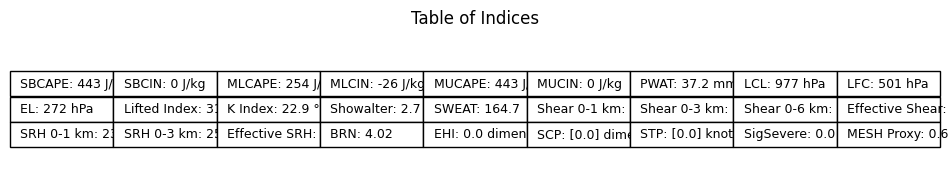

In [29]:
# Re-create the list of indices to ensure a clean state
lcl_str = f"{lcl_sb[0]:.0f~P}" if lcl_sb[0] is not None else "N/A"
lfc_str = f"{lfc_sb[0]:.0f~P}" if lfc_sb[0] is not None else "N/A"
el_str = f"{el_sb[0]:.0f~P}" if el_sb[0] is not None else "N/A"

# Check if EL_sb is None before formatting
el_formatted = f"{el_sb[0]:.0f~P}" if el_sb[0] is not None else "N/A"

# Ensure mesh_proxy is a string before adding to the list
mesh_proxy_str = str(mesh_proxy)


all_indices_for_table = [
    f"SBCAPE: {cape_sb:.0f~P}", f"SBCIN: {cin_sb:.0f~P}", f"MLCAPE: {cape_ml:.0f~P}",
    f"MLCIN: {cin_ml:.0f~P}", f"MUCAPE: {cape_mu:.0f~P}", f"MUCIN: {cin_mu:.0f~P}",
    f"PWAT: {pwat:.1f~P}", f"LCL: {lcl_str}", f"LFC: {lfc_str}",
    f"EL: {el_formatted}", # Use the formatted EL string
    f"Lifted Index: {li:.1f~P}", f"K Index: {k_index:.1f~P}",
    f"Showalter: {showalter:.1f~P}", f"SWEAT: {sweat:.1f~P}", f"Shear 0-1 km: {mpcalc.wind_speed(shear_0_1km[0], shear_0_1km[1]):.1f~P}",
    f"Shear 0-3 km: {mpcalc.wind_speed(shear_0_3km[0], shear_0_3km[1]):.1f~P}", f"Shear 0-6 km: {mpcalc.wind_speed(shear_0_6km[0], shear_0_6km[1]):.1f~P}", f"Effective Shear: {mpcalc.wind_speed(effective_shear[0], effective_shear[1]):.1f~P}",
    f"SRH 0-1 km: {srh_0_1km:.0f~P}", f"SRH 0-3 km: {srh_0_3km:.0f~P}", f"Effective SRH: {effective_srh:.0f~P}",
    f"BRN: {brn:.2f~P}", f"EHI: {ehi:.1f}", f"SCP: {scp:.1f}",
    f"STP: {stp:.1f}", f"SigSevere: {sigsevere:.1f}", f"MESH Proxy: {mesh_proxy_str}" # Ensure mesh_proxy is a string
]

# Add a print statement to check the length of the list before reshaping
print(f"Length of all_indices_for_table: {len(all_indices_for_table)}")
# Add a print statement to see the content of the list
print("Content of all_indices_for_table:", all_indices_for_table)


# Reshape the list and create the table
expected_elements = 27 # Based on the number of indices in the list
if len(all_indices_for_table) == expected_elements:
    table_data = np.reshape(all_indices_for_table, (3, 9)).tolist()

    # Create a new figure and axes for the table
    fig_table, ax_table = plt.subplots(figsize=(12, 2)) # Adjust figure size as needed
    ax_table.axis('off')

    table = ax_table.table(cellText=table_data, loc='center', cellLoc='left', edges='closed')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)

    plt.title("Table of Indices") # Add a title for the table
    plt.show()
else:
    print(f"Warning: all_indices_for_table has {len(all_indices_for_table)} elements, expected {expected_elements} for the table. Skipping table generation.")

### Diagrama Skew-T Log-P

Este gráfico é um diagrama Skew-T log-P, um diagrama termodinâmico amplamente utilizado em meteorologia para exibir sondagens atmosféricas e analisar a estabilidade atmosférica.

* **Eixos:**
  * O **eixo horizontal** representa a **temperatura**, inclinada em um ângulo (geralmente 45 graus) em relação às isóbaras (linhas de pressão constante).
  * O **eixo vertical** representa o **logaritmo da pressão**, aumentando para baixo.
* **Linhas no Diagrama:**
  * **Isóbaras:** Linhas horizontais representando pressão constante.
  * **Isotermas:** Linhas inclinadas representando temperatura constante.
  * **Adiabáticas Secas:** Linhas representando a mudança de temperatura de uma parcela de ar seco levantada ou abaixada adiabaticamente.
  * **Adiabáticas Úmidas:** Linhas representando a mudança de temperatura de uma parcela de ar saturado levantada ou abaixada adiabaticamente, considerando a liberação de calor latente durante a condensação.
  * **Linhas de Razão de Mistura:** Linhas representando razão de mistura constante (a massa de vapor d'água por unidade de massa de ar seco).
* **Dados Plotados:**
  * A **linha vermelha** geralmente representa o **perfil de temperatura do ar** com a altura (ou pressão).
  * A **linha verde** geralmente representa o **perfil de temperatura do ponto de orvalho** com a altura (ou pressão).
  * A **linha preta** representa o **traçado da parcela**, mostrando a temperatura e pressão de uma parcela de ar levantada (geralmente uma parcela de superfície, mas outros níveis podem ser escolhidos).
* **Interpretação:**
  * A separação entre os perfis de temperatura e ponto de orvalho indica a quantidade de umidade na atmosfera. Uma grande separação significa ar seco, enquanto uma pequena separação significa ar úmido.
  * A relação entre o perfil de temperatura ambiental e as adiabáticas secas e úmidas indica a estabilidade atmosférica.
    * Se o perfil de temperatura ambiental estiver à direita de uma adiabática seca, a camada é absolutamente instável para ascensão seca.
    * Se o perfil de temperatura ambiental estiver à esquerda de uma adiabática seca, mas à direita de uma adiabática úmida, a camada é condicionalmente instável.
    * Se o perfil de temperatura ambiental estiver à esquerda de uma adiabática úmida, a camada é absolutamente estável para ascensão saturada.
  * A **Energia Potencial de Convecção Disponível (CAPE)** é a área no Skew-T onde a temperatura da parcela levantada é mais quente que a temperatura ambiental (flutuabilidade positiva). Ela representa a energia potencial disponível para convecção.
  * A **Inibição Convectiva (CIN)** é a área onde a temperatura da parcela levantada é mais fria que a temperatura ambiental (flutuabilidade negativa) abaixo do Nível de Convecção Livre (LFC). Ela representa a barreira de energia que deve ser superada para que a convecção ocorra.
  * Outras características como o **Nível de Condensação por Levantamento (LCL)**, **Nível de Convecção Livre (LFC)** e **Nível de Equilíbrio (EL)** podem ser identificadas no diagrama e fornecem insights adicionais sobre o potencial de desenvolvimento de tempestades.

In [30]:
all_indices

['SBCAPE: 443 J/kg',
 'SBCIN: 0 J/kg',
 'MUCAPE: 443 J/kg',
 'MUCIN: 0 J/kg',
 'PWAT: 37.2 mm',
 'LCL: 977 hPa',
 'LFC: 501 hPa',
 'EL: 272 hPa',
 'Lifted Index: 31.6 K',
 'K Index: 22.9 °C',
 'Showalter: 2.7 °C',
 'Shear 0-6 km: 18.2 kt',
 'SRH 0-1 km: 23 m²/s²',
 'SRH 0-3 km: 25 m²/s²',
 'Effective SRH: 16 m²/s²']

In [31]:
# @title
from IPython.display import Markdown
import numpy as np

# Usando o dicionário 'indices' criado anteriormente para evitar erros de índice fixo
# Se o dicionário não existir por algum motivo, criamos uma versão segura com fallback para 'N/A'
try:
    indices_dict = indices
except NameError:
    indices_dict = {}

def get_val(key):
    return indices_dict.get(key, "N/A")

markdown_text = f"""
## Explicação dos Índices Meteorológicos e Valores de Referência

Abaixo, apresentamos a explicação de cada um dos parâmetros calculados para a sondagem atual e alguns valores de referência para análise:

* **SBCAPE (Surface-Based Convective Available Potential Energy):** Energia potencial disponível para convecção baseada em uma parcela de ar levantada a partir da superfície. Valores altos indicam maior potencial para tempestades.
  * **Valor Calculado:** {get_val('SBCAPE')}
  * **Valores de Referência:**
    * Baixo: < 500 J/kg
    * Moderado: 500 - 1500 J/kg
    * Alto: 1500 - 3000 J/kg
    * Muito Alto: > 3000 J/kg

* **SBCIN (Surface-Based Convective Inhibition):** Energia que impede a ascensão de uma parcela de ar a partir da superfície. Valores negativos (ou próximos de zero) indicam pouca ou nenhuma inibição para o desenvolvimento de convecção.
  * **Valor Calculado:** {get_val('SBCIN')}
  * **Valores de Referência:**
    * Significativa: < -100 J/kg
    * Moderada: -100 a -25 J/kg
    * Fraca: -25 a 0 J/kg
    * Nula ou Positiva: >= 0 J/kg

* **MUCAPE (Most Unstable Convective Available Potential Energy):** O maior valor de CAPE encontrado ao levantar parcelas a partir de todos os níveis na sondagem. Indica o maior potencial de energia disponível para convecção, independentemente do nível de origem.
  * **Valor Calculado:** {get_val('MUCAPE')}
  * **Valores de Referência:** Similares aos do SBCAPE, mas indica o potencial máximo de energia disponível.

* **MUCIN (Most Unstable Convective Inhibition):** CIN associado à parcela mais instável (aquela que produziu a MUCAPE).
  * **Valor Calculado:** {get_val('MUCIN')}
  * **Valores de Referência:** Similares aos do SBCIN, associado ao potencial máximo de convecção.

* **PWAT (Precipitable Water):** Quantidade total de vapor d'água em uma coluna vertical da atmosfera. Representa o potencial máximo de precipitação. Valores altos indicam uma atmosfera muito úmida.
  * **Valor Calculado:** {get_val('PWAT')}
  * **Valores de Referência:** Variam sazonal e geograficamente. Valores acima da média climática local indicam maior umidade disponível para precipitação.

* **LCL (Lifting Condensation Level):** Nível onde uma parcela de ar levantada se torna saturada e a condensação começa a ocorrer (formação de nuvens).
  * **Valor Calculado:** {get_val('LCL')}
  * **Valores de Referência:** LCLs mais baixos (pressões mais altas) indicam que as nuvens se formarão mais perto da superfície, o que pode favorecer o desenvolvimento de tornados em ambientes com cisalhamento adequado.

* **LFC (Level of Free Convection):** Nível onde uma parcela de ar levantada se torna mais quente que o ambiente e começa a ascender livremente devido à flutuabilidade positiva.
  * **Valor Calculado:** {get_val('LFC')}
  * **Valores de Referência:** A existência de um LFC abaixo do EL indica potencial para convecção. A altura do LFC influencia a profundidade da camada de CIN.

* **EL (Equilibrium Level):** Nível onde a temperatura de uma parcela de ar ascendente se iguala à temperatura do ambiente novamente, e a flutuabilidade se torna neutra ou negativa. Frequentemente associado ao topo das nuvens de tempestade.
  * **Valor Calculado:** {get_val('EL')}
  * **Valores de Referência:** A altura do EL indica até onde as correntes ascendentes podem se estender. ELs mais altos estão associados a tempestades mais intensas e potencial para granizo maior.

* **Lifted Index:** Índice simples de estabilidade. Calcula a diferença entre a temperatura do ambiente e a temperatura de uma parcela levantada no nível de 500 hPa. Valores negativos indicam instabilidade.
  * **Valor Calculado:** {get_val('Lifted Index')}
  * **Valores de Referência:**
    * > 0: Estável
    * 0 a -2: Ligeiramente Instável
    * -2 a -6: Moderadamente Instável
    * < -6: Muito Instável

* **K Index:** Índice que avalia o potencial de desenvolvimento de tempestades não severas baseadas em umidade e gradientes de temperatura em diferentes níveis. Valores mais altos indicam maior potencial para chuvas e tempestades.
  * **Valor Calculado:** {get_val('K Index')}
  * **Valores de Referência:**
    * < 15: Sem Potencial para Tempestades
    * 15 - 20: Pequeno Potencial
    * 20 - 25: Potencial Moderado para Chuvas e Tempestades
    * 25 - 30: Potencial Moderado para Tempestades
    * 30 - 35: Potencial para Tempestades Generalizadas
    * > 35: Potencial para Tempestades Fortes

* **Showalter Index:** Índice de estabilidade calculado levantando-se uma parcela a partir do nível de 850 hPa até 500 hPa. Semelhante ao Lifted Index, valores negativos indicam instabilidade.
  * **Valor Calculado:** {get_val('Showalter')}
  * **Valores de Referência:**
    * > +4: Estável
    * +1 a +4: Ligeiramente Instável
    * -2 a +1: Moderadamente Instável
    * < -2: Muito Instável

* **Shear 0-6 km:** Medida do cisalhamento vertical do vento nos primeiros 6 quilômetros acima da superfície. Importante para a organização de tempestades e potencial de supercélulas.
  * **Valor Calculado:** {get_val('Shear 0-6 km')}
  * **Valores de Referência:**
    * Baixo: < 20 kt
    * Moderado: 20 - 40 kt
    * Alto: > 40 kt (favorável para supercélulas e tempo severo organizado)

* **SRH 0-1 km (Storm-Relative Helicity 0-1 km):** Medida do potencial rotacional em uma tempestade nos primeiros 1 quilômetro acima da superfície. Associado ao potencial de tornados.
  * **Valor Calculado:** {get_val('SRH 0-1 km')}
  * **Valores de Referência:**
    * Baixo: < 100 m²/s²
    * Moderado: 100 - 200 m²/s²
    * Alto: > 200 m²/s²

* **SRH 0-3 km (Storm-Relative Helicity 0-3 km):** Medida do potencial rotacional nos primeiros 3 quilômetros acima da superfície. Associado ao potencial de supercélulas.
  * **Valor Calculado:** {get_val('SRH 0-3 km')}
  * **Valores de Referência:**
    * Baixo: < 150 m²/s²
    * Moderado: 150 - 250 m²/s²
    * Alto: > 250 m²/s²

* **Effective SRH:** Medida do potencial rotacional na camada efetiva de tempestade (entre o LFC e o EL).
  * **Valor Calculado:** {get_val('Effective SRH')}

* **SCP (Supercell Composite Parameter):** Índice composto para identificar ambientes favoráveis ao desenvolvimento de supercélulas.
  * **Valor Calculado:** {get_val('SCP')}

* **STP (Significant Tornado Parameter):** Índice composto para avaliar o potencial de tornados significativos.
  * **Valor Calculado:** {get_val('STP')}

* **MESH:** Estimativa do Tamanho Máximo Esperado de Granizo (Maximum Expected Hail Size).
  * **Valor Calculado:** {get_val('MESH')}
"""

display(Markdown(markdown_text))


## Explicação dos Índices Meteorológicos e Valores de Referência

Abaixo, apresentamos a explicação de cada um dos parâmetros calculados para a sondagem atual e alguns valores de referência para análise:

* **SBCAPE (Surface-Based Convective Available Potential Energy):** Energia potencial disponível para convecção baseada em uma parcela de ar levantada a partir da superfície. Valores altos indicam maior potencial para tempestades.
  * **Valor Calculado:** 443 J/kg
  * **Valores de Referência:**
    * Baixo: < 500 J/kg
    * Moderado: 500 - 1500 J/kg
    * Alto: 1500 - 3000 J/kg
    * Muito Alto: > 3000 J/kg

* **SBCIN (Surface-Based Convective Inhibition):** Energia que impede a ascensão de uma parcela de ar a partir da superfície. Valores negativos (ou próximos de zero) indicam pouca ou nenhuma inibição para o desenvolvimento de convecção.
  * **Valor Calculado:** 0 J/kg
  * **Valores de Referência:**
    * Significativa: < -100 J/kg
    * Moderada: -100 a -25 J/kg
    * Fraca: -25 a 0 J/kg
    * Nula ou Positiva: >= 0 J/kg

* **MUCAPE (Most Unstable Convective Available Potential Energy):** O maior valor de CAPE encontrado ao levantar parcelas a partir de todos os níveis na sondagem. Indica o maior potencial de energia disponível para convecção, independentemente do nível de origem.
  * **Valor Calculado:** 443 J/kg
  * **Valores de Referência:** Similares aos do SBCAPE, mas indica o potencial máximo de energia disponível.

* **MUCIN (Most Unstable Convective Inhibition):** CIN associado à parcela mais instável (aquela que produziu a MUCAPE).
  * **Valor Calculado:** 0 J/kg
  * **Valores de Referência:** Similares aos do SBCIN, associado ao potencial máximo de convecção.

* **PWAT (Precipitable Water):** Quantidade total de vapor d'água em uma coluna vertical da atmosfera. Representa o potencial máximo de precipitação. Valores altos indicam uma atmosfera muito úmida.
  * **Valor Calculado:** 37.2 mm
  * **Valores de Referência:** Variam sazonal e geograficamente. Valores acima da média climática local indicam maior umidade disponível para precipitação.

* **LCL (Lifting Condensation Level):** Nível onde uma parcela de ar levantada se torna saturada e a condensação começa a ocorrer (formação de nuvens).
  * **Valor Calculado:** 977 hPa
  * **Valores de Referência:** LCLs mais baixos (pressões mais altas) indicam que as nuvens se formarão mais perto da superfície, o que pode favorecer o desenvolvimento de tornados em ambientes com cisalhamento adequado.

* **LFC (Level of Free Convection):** Nível onde uma parcela de ar levantada se torna mais quente que o ambiente e começa a ascender livremente devido à flutuabilidade positiva.
  * **Valor Calculado:** 501 hPa
  * **Valores de Referência:** A existência de um LFC abaixo do EL indica potencial para convecção. A altura do LFC influencia a profundidade da camada de CIN.

* **EL (Equilibrium Level):** Nível onde a temperatura de uma parcela de ar ascendente se iguala à temperatura do ambiente novamente, e a flutuabilidade se torna neutra ou negativa. Frequentemente associado ao topo das nuvens de tempestade.
  * **Valor Calculado:** 272 hPa
  * **Valores de Referência:** A altura do EL indica até onde as correntes ascendentes podem se estender. ELs mais altos estão associados a tempestades mais intensas e potencial para granizo maior.

* **Lifted Index:** Índice simples de estabilidade. Calcula a diferença entre a temperatura do ambiente e a temperatura de uma parcela levantada no nível de 500 hPa. Valores negativos indicam instabilidade.
  * **Valor Calculado:** 31.6 K
  * **Valores de Referência:**
    * > 0: Estável
    * 0 a -2: Ligeiramente Instável
    * -2 a -6: Moderadamente Instável
    * < -6: Muito Instável

* **K Index:** Índice que avalia o potencial de desenvolvimento de tempestades não severas baseadas em umidade e gradientes de temperatura em diferentes níveis. Valores mais altos indicam maior potencial para chuvas e tempestades.
  * **Valor Calculado:** 22.9 °C
  * **Valores de Referência:**
    * < 15: Sem Potencial para Tempestades
    * 15 - 20: Pequeno Potencial
    * 20 - 25: Potencial Moderado para Chuvas e Tempestades
    * 25 - 30: Potencial Moderado para Tempestades
    * 30 - 35: Potencial para Tempestades Generalizadas
    * > 35: Potencial para Tempestades Fortes

* **Showalter Index:** Índice de estabilidade calculado levantando-se uma parcela a partir do nível de 850 hPa até 500 hPa. Semelhante ao Lifted Index, valores negativos indicam instabilidade.
  * **Valor Calculado:** 2.7 °C
  * **Valores de Referência:**
    * > +4: Estável
    * +1 a +4: Ligeiramente Instável
    * -2 a +1: Moderadamente Instável
    * < -2: Muito Instável

* **Shear 0-6 km:** Medida do cisalhamento vertical do vento nos primeiros 6 quilômetros acima da superfície. Importante para a organização de tempestades e potencial de supercélulas.
  * **Valor Calculado:** 18.2 kt
  * **Valores de Referência:**
    * Baixo: < 20 kt
    * Moderado: 20 - 40 kt
    * Alto: > 40 kt (favorável para supercélulas e tempo severo organizado)

* **SRH 0-1 km (Storm-Relative Helicity 0-1 km):** Medida do potencial rotacional em uma tempestade nos primeiros 1 quilômetro acima da superfície. Associado ao potencial de tornados.
  * **Valor Calculado:** 23 m²/s²
  * **Valores de Referência:**
    * Baixo: < 100 m²/s²
    * Moderado: 100 - 200 m²/s²
    * Alto: > 200 m²/s²

* **SRH 0-3 km (Storm-Relative Helicity 0-3 km):** Medida do potencial rotacional nos primeiros 3 quilômetros acima da superfície. Associado ao potencial de supercélulas.
  * **Valor Calculado:** 25 m²/s²
  * **Valores de Referência:**
    * Baixo: < 150 m²/s²
    * Moderado: 150 - 250 m²/s²
    * Alto: > 250 m²/s²

* **Effective SRH:** Medida do potencial rotacional na camada efetiva de tempestade (entre o LFC e o EL).
  * **Valor Calculado:** 16 m²/s²

* **SCP (Supercell Composite Parameter):** Índice composto para identificar ambientes favoráveis ao desenvolvimento de supercélulas.
  * **Valor Calculado:** N/A

* **STP (Significant Tornado Parameter):** Índice composto para avaliar o potencial de tornados significativos.
  * **Valor Calculado:** N/A

* **MESH:** Estimativa do Tamanho Máximo Esperado de Granizo (Maximum Expected Hail Size).
  * **Valor Calculado:** N/A




---
# AGORA iremos fazer outra analises sobre essa mesma sondagem


In [32]:
#Adaptando as variaveis para usar códigos do Matlab
p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC
u = df['u_wind'].values * units.knots
v = df['v_wind'].values * units.knots
Z=mpcalc.pressure_to_height_std(p)
zz=Z.to("meter")
theta=mpcalc.potential_temperature(p,T)
thetae=mpcalc.equivalent_potential_temperature(p, T, Td)
rh=mpcalc.relative_humidity_from_dewpoint(T,Td)
mixrat=mpcalc.mixing_ratio_from_relative_humidity(p,T,rh)
thetas=mpcalc.equivalent_potential_temperature(p,T,T)
pw = mpcalc.precipitable_water(p, Td)
S=mpcalc.static_stability(p,T.to('kelvin'))
N=mpcalc.brunt_vaisala_frequency(zz,theta)
pw # precipitable Water!!


Quantity(np.float64(37.18338503061629), "millimeter")

In [33]:
import pandas as pd

# Assuming all calculated variables have the same length
data = {
    'Pressure (hPa)': p.magnitude,
    'Height (m)': zz.magnitude,
    'Temperature (degC)': T.magnitude,
    'Dewpoint (degC)': Td.magnitude,
    'U Wind (knots)': u.magnitude,
    'V Wind (knots)': v.magnitude,
    'Potential Temperature (K)': theta.magnitude,
    'Equivalent Potential Temperature (K)': thetae.magnitude,
    'Relative Humidity (%)': rh.magnitude,
    'Mixing Ratio (g/kg)': mixrat.to('g/kg').magnitude,
    'Saturation Potential Temperature (K)': thetas.magnitude,
    'Static Stability (K/km)': S.magnitude,
    'Brunt-Vaisala Frequency (s^-1)': N.magnitude
}

# Find the minimum length of all arrays to handle potential discrepancies
min_len = min(len(arr) for arr in data.values())

# Truncate all arrays to the minimum length
truncated_data = {key: arr[:min_len] for key, arr in data.items()}


df_calculated = pd.DataFrame(truncated_data)
display(df_calculated)

,Pressure (hPa),Height (m),Temperature (degC),Dewpoint (degC),U Wind (knots),V Wind (knots),Potential Temperature (K),Equivalent Potential Temperature (K),Relative Humidity (%),Mixing Ratio (g/kg),Saturation Potential Temperature (K),Static Stability (K/km),Brunt-Vaisala Frequency (s^-1)
0,1018.1,-40.272692,22.4,19.6,-3.382893,-1.231273,294.039127,334.824120,0.842076,14.232200,342.630672,-0.034898,NaN
1,1013.7,-3.743203,21.6,18.7,0.797816,-5.037211,293.606321,332.239669,0.835935,13.499287,339.943108,-0.020929,NaN
2,1000.0,110.824632,20.5,18.4,1.602796,-8.245668,293.650000,332.085613,0.877677,13.428261,337.511326,0.002561,0.005931
3,985.6,232.624593,19.5,17.6,2.894192,-10.093248,293.865315,330.974289,0.887913,12.946651,335.702126,0.005218,0.008380
4,947.5,561.982865,17.2,15.5,0.526982,-15.090801,294.858385,328.772240,0.897431,11.762561,332.654227,0.007039,0.009461
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,41.7,20160.912859,-61.4,-88.9,1.486854,-0.824176,524.892371,524.925075,0.016697,0.004032,526.545484,15.417414,0.030711
80,40.0,20351.374168,-62.1,-88.4,4.949465,-5.898542,529.415665,529.453013,0.019912,0.004582,531.010224,9.421991,0.023014
81,35.8,20851.692745,-60.7,-88.5,6.483879,-2.359939,550.089067,550.131754,0.016364,0.005032,552.288487,19.613771,0.030077
82,35.3,20914.376786,-60.3,-88.3,7.468643,-2.866944,553.343952,553.388977,0.016100,0.005282,555.699854,15.940066,0.026827


### Gráfico de Temperatura Potencial, Temperatura Potencial Equivalente e Temperatura Potencial de Saturação

Este gráfico exibe três perfis de temperatura diferentes em função da pressão:

*   **Temperatura Potencial ($\theta$)**: A temperatura que uma parcela de ar seco teria se fosse movida adiabaticamente para uma pressão padrão de 1000 hPa. É conservada durante processos adiabáticos secos.
*   **Temperatura Potencial Equivalente ($\theta_e$)**: A temperatura que uma parcela de ar teria se toda a sua umidade fosse condensada e o calor latente liberado, e a parcela fosse então movida adiabaticamente para uma pressão padrão de 1000 hPa. É conservada durante processos adiabáticos secos e úmidos.
*   **Temperatura Potencial de Saturação ($\theta_s$)**: A temperatura potencial de uma parcela de ar saturado.
*   **Interpretação:**
    *   O perfil vertical da temperatura potencial indica **estabilidade estática** em ar seco. Se a temperatura potencial aumenta com a altura, a camada é estável em relação a deslocamentos adiabáticos secos.
    *   O perfil vertical da temperatura potencial equivalente indica **estabilidade estática** em ar saturado. Se a temperatura potencial equivalente aumenta com a altura, a camada é estável em relação a deslocamentos adiabáticos úmidos.
    *   Comparar os perfis de $\theta$, $\theta_e$ e $\theta_s$ pode fornecer insights sobre a estabilidade atmosférica e o potencial para convecção. Por exemplo, se $\theta_e$ diminui com a altura, a atmosfera é condicionalmente instável.

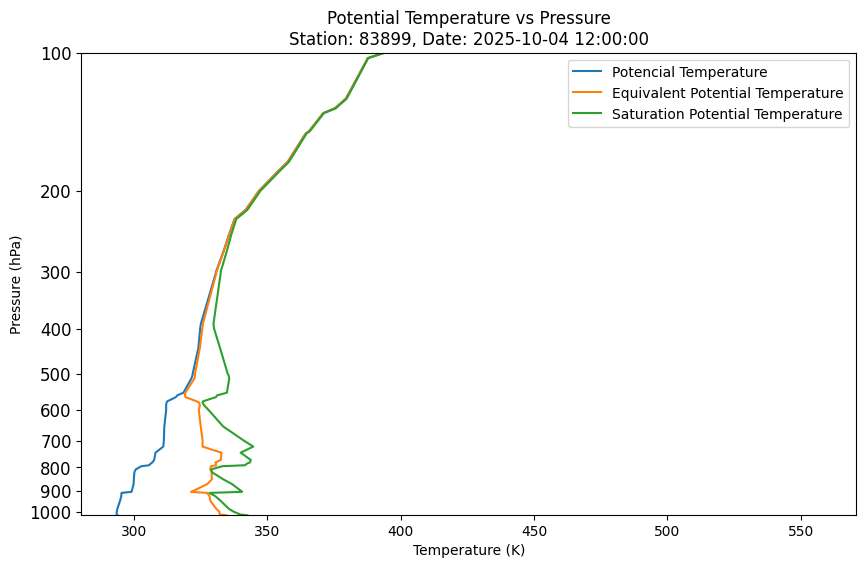

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(theta, p, label='Potencial Temperature')
ax.plot(thetae, p, label='Equivalent Potential Temperature')
ax.plot(thetas, p, label='Saturation Potential Temperature')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title(f'Potential Temperature vs Pressure\nStation: {station}, Date: {date.strftime("%Y-%m-%d %H:%M:%S")}')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_ylim(1015, 100)

# Define os ticks do eixo y
yticks = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks])  # mostra valores

ax.legend()
ax.tick_params(axis='y', labelsize=12)

plt.show()


### Gráfico da Frequência de Brunt-Vaisala

Este gráfico mostra a **Frequência de Brunt-Vaisala (N)** em função da pressão. A frequência de Brunt-Vaisala é uma medida da frequência com que uma parcela de ar deslocada verticalmente irá oscilar em uma atmosfera estavelmente estratificada.

*   **Interpretação:**
    *   **Valores mais altos de N** indicam uma atmosfera **mais estável** e oscilações mais fortes. Isso significa que a atmosfera é mais resistente ao movimento vertical.
    *   **Valores mais baixos de N** indicam uma atmosfera **menos estável** e oscilações mais fracas.
    *   Em uma atmosfera **instável**, a frequência de Brunt-Vaisala é **imaginária**, e as parcelas acelerarão para longe de sua posição original em vez de oscilar. O gráfico mostra apenas valores reais de N, que correspondem a condições estáveis.

A frequência de Brunt-Vaisala está relacionada à estabilidade estática (S), com maior estabilidade estática correspondendo a maiores frequências de Brunt-Vaisala em condições estáveis.

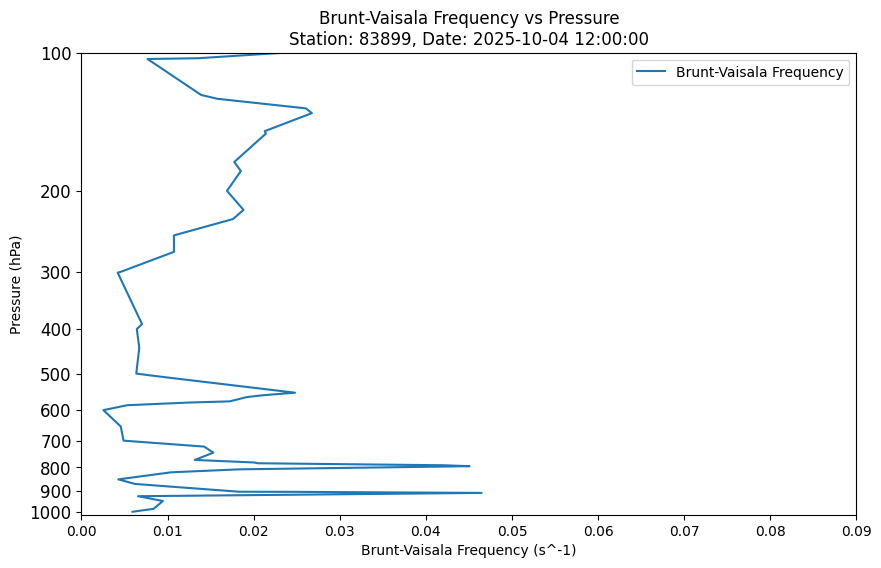

In [35]:
#plotar  a frequencia de Brunt-Vaisala   em funcao de pressão num grafico

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(N, p, label='Brunt-Vaisala Frequency')


ax.set_xlabel('Brunt-Vaisala Frequency (s^-1)') # Removed Static Stability from label as it is plotted separately now
ax.set_ylabel('Pressure (hPa)')
ax.set_title(f'Brunt-Vaisala Frequency vs Pressure\nStation: {station}, Date: {date.strftime("%Y-%m-%d %H:%M:%S")}') # Updated title
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_ylim(1015, 100)  # Set y-axis limits to 1015 hPa to 100 hPa
ax.set_xlim(0, 0.09) # Set x-axis limits based on typical values

# Define os ticks do eixo y
yticks = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks])  # mostra valores

ax.legend()
ax.tick_params(axis='y', labelsize=12) # Increase y-axis tick label font size

plt.show()

### Gráfico da Estabilidade Estática

Este gráfico mostra a **Estabilidade Estática (S)** em função da pressão. A estabilidade estática é uma medida de se uma parcela de ar retornará à sua posição original após ser deslocada verticalmente.

*   **Interpretação:**
    *   **Valores positivos de S** indicam uma atmosfera com **estratificação estável**. Uma parcela deslocada experimentará uma força restauradora e retornará ao seu nível original.
    *   **Valores negativos de S** indicam uma atmosfera com **estratificação instável**. Uma parcela deslocada acelerará para longe de seu nível original.
    *   **Valores de S próximos de zero** indicam uma atmosfera com **estratificação neutra**. Uma parcela deslocada permanecerá em seu novo nível.

Valores positivos mais altos de estabilidade estática indicam uma resistência maior ao movimento vertical, enquanto valores negativos indicam condições favoráveis para convecção.

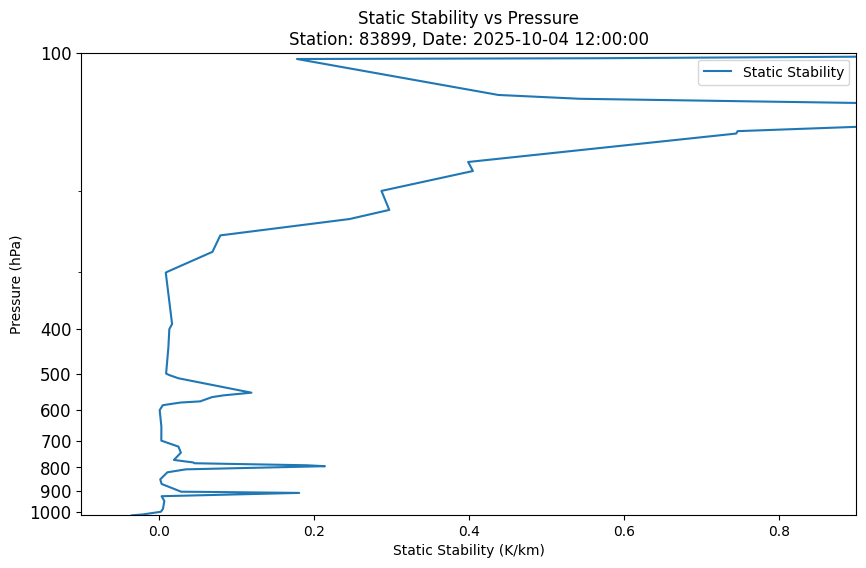

In [36]:
# prompt: plotar a estabilidade estatica S em funcao de pressão em um grafico

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(S, p, label='Static Stability')

ax.set_xlabel('Static Stability (K/km)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title(f'Static Stability vs Pressure\nStation: {station}, Date: {date.strftime("%Y-%m-%d %H:%M:%S")}')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_ylim(1015, 100)  # Set y-axis limits to 1015 hPa to 100 hPa
ax.set_xlim(-0.1, 0.9) # Set x-axis limits based on typical values
# Define os ticks do eixo y
yticks = [1000, 900, 800, 700, 600, 500, 400, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks])  # mostra valores

ax.legend()
ax.tick_params(axis='y', labelsize=12) # Increase y-axis tick label font size

plt.show()

### Gráficos de Diferença de Temperatura de Densidade

Estes gráficos de contorno mostram a **Diferença de Temperatura de Densidade (DTD)**, que é uma medida de flutuabilidade. A DTD é calculada para parcelas levantadas de vários níveis de pressão (Pressão de Origem da Parcela no eixo x) para diferentes níveis de pressão (Pressão para a qual a Parcela é Levantada no eixo y).

*   **Interpretação:**
    *   **Valores positivos de DTD** indicam que uma parcela levantada está mais quente e menos densa do que o ambiente circundante naquele nível de pressão, o que significa que ela é flutuante e continuará a subir. Áreas com grandes valores positivos de DTD sugerem potencial para fortes correntes ascendentes e instabilidade.
    *   **Valores negativos de DTD** indicam que uma parcela levantada está mais fria e mais densa do que o ambiente circundante, o que significa que ela é negativamente flutuante e afundará. Áreas com valores negativos de DTD representam camadas estáveis.

Os dois gráficos mostram a DTD calculada usando diferentes suposições:

*   **Diferença de Temperatura de Densidade Pseudo-adiabática Média:** Assume que a parcela levantada segue um processo pseudo-adiabático (toda a água condensada cai imediatamente).
*   **Diferença de Temperatura de Densidade Reversível Média:** Assume que a parcela levantada segue um processo reversível (toda a água condensada permanece com a parcela).

Comparar esses dois gráficos pode fornecer insights sobre o impacto potencial do carregamento de precipitação na flutuabilidade da parcela.


---
---

### Programa em Fortran: Compilação e Execução de wyoming.f

Esta seção do script envolve um programa separado escrito em Fortran, denominado `wyoming.f`.

* **Origem de `wyoming.f`**: O arquivo `wyoming.f` é um arquivo de código-fonte em Fortran fornecido como parte do ambiente deste notebook. Sua origem ou autor específico não são detalhados no próprio notebook, mas, com base em seu nome e uso, ele foi projetado para processar dados de sondagem, provavelmente em um formato compatível com os dados obtidos no site Wyoming Upper Air Soundings.
## Mais detalhes olhar em
https://ocw.mit.edu/courses/12-811-tropical-meteorology-spring-2011/pages/tools/

In [37]:
sounding="http://weather.uwyo.edu/cgi-bin/sounding?region=samer&TYPE=TEXT%3ALIST&YEAR="+str(yy)+"&MONTH="+str(mm)+"&FROM="+str(dd)+str(hh)+"&TO="+str(dd)+str(hh)+"&STNM="+station
output = subprocess.run(["wget",sounding , '-O','sounding.htm'])

! cat sounding.htm | html2text -o sounding.txt

In [38]:
!find -name sounding.txt

./sounding.txt


In [39]:
!wget https://texmex.mit.edu/pub/emanuel/soundings/wyoming.f
!gfortran -o wyoming.exe wyoming.f

--2026-10-05 21:37:33--  https://texmex.mit.edu/pub/emanuel/soundings/wyoming.f
Resolving texmex.mit.edu (texmex.mit.edu)... 18.18.83.64
Connecting to texmex.mit.edu (texmex.mit.edu)|18.18.83.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17281 (17K) [application/octet-stream]
Saving to: ‘wyoming.f’

wyoming.f           100%[===================>]  16.88K  --.-KB/s    in 0s      

2026-10-05 21:37:34 (201 MB/s) - ‘wyoming.f’ saved [17281/17281]



In [40]:
!./wyoming.exe


At line 63 of file wyoming.f (unit = 11, file = 'sounding.txt')
Fortran runtime error: End of file

Error termination. Backtrace:
#0  0x7c098f011e59 in ???
#1  0x7c098f012a71 in ???
#2  0x7c098f2a96c3 in ???
#3  0x7c098f2ad7e7 in ???
#4  0x7c098f2ad8f5 in ???
#5  0x5bdb6b1a860f in MAIN__
#6  0x5bdb6b1ae3b6 in main


In [41]:
import pandas as pd
pp=pd.read_fwf('p.out',names=['P'])
porig=pd.read_fwf('porig.out',names=['Porig'])
tdifrev=pd.read_fwf('tdifrev.out')
tdifpseudo=pd.read_fwf('tdifpseudo.out')
f=open('header.txt','r')
# Correct the variable assignment to avoid overwriting the datetime 'date'
# [name,time,month,date,year]=[station,yy,mm,dd,hh] # Incorrect reassignment
# Instead, read header info without reassigning 'date'
header_info = f.readline().split()
name = header_info[0]
time_str = header_info[4]
month_str = header_info[2]
date_str = header_info[3]
year_str = header_info[1]
f.close()

modsound=pd.read_fwf('modsound.txt',names=['Pr','Temp','Rh'])

FileNotFoundError: [Errno 2] No such file or directory: 'p.out'

In [ ]:
pr=modsound['Pr'];
tc=modsound['Temp'];
rh=modsound['Rh'];


In [ ]:
X, Y = np.meshgrid(porig,pp.iloc[0:-1])
tdifpseudo.shape
tdifrev.shape

In [ ]:
from IPython.display import set_matplotlib_formats
from matplotlib_inline.backend_inline import set_matplotlib_formats as set_matplotlib_formats_inline
%matplotlib inline
set_matplotlib_formats_inline('png')

import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np


# Initialize plot objects
rcParams['figure.figsize'] = 6, 6 # sets plot size
fig = plt.figure()
title='Mean Pseudo-adiabatic Density Temperature Difference (K)\n \
Station = '+ str(name)+ '   '+ str(hh)+ 'Z '+ str(dd) +' '+ str(mm) +' '+ str(yy);
fig.suptitle(title, fontsize=12)
ax = fig.add_subplot(111)

# Generate a contour plot
cp = ax.contourf(X,Y,tdifpseudo,cmap='jet');
#ax.clabel(cp, inline=2,fmt='%4.0f', colors='w',  fontsize=8)
fig.colorbar(cp, orientation='horizontal')
ax.invert_yaxis()
ax.invert_xaxis()

# Set y-axis to logarithmic scale and adjust limits
ax.set_yscale('log')
ax.set_ylim(Y.max(), Y.min()) # Set limits based on the range of Y

# Set specific y-ticks
yticks = [1000, 900, 800, 700, 600, 500, 400, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks])  # show values

ax.set_xlabel('Parcel Origin Pressure (mb)', fontsize=10)
ax.set_ylabel('Pressure to which Parcel is Lifted (mb)', fontsize=10) # Label is already in mb

plt.show()
plt.savefig('tdadiabatico.png')

In [ ]:
from IPython.display import set_matplotlib_formats
from matplotlib_inline.backend_inline import set_matplotlib_formats as set_matplotlib_formats_inline
%matplotlib inline
set_matplotlib_formats_inline('png')

import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np


# Initialize plot objects
rcParams['figure.figsize'] = 6, 6 # sets plot size
fig = plt.figure()
title='Mean Reversible Density Temperature Difference (K)\n \
Station = '+ str(name)+ '   '+ str(hh)+ 'Z '+ str(dd) +' '+ str(mm) +' '+ str(yy);
fig.suptitle(title, fontsize=12)
ax = fig.add_subplot(111)

# Generate a contour plot
cp = ax.contourf(X,Y,tdifrev,cmap='jet');
#ax.clabel(cp, inline=1,fmt='%2.1f', colors='w',  fontsize=10)
fig.colorbar(cp, orientation='horizontal')
ax.invert_yaxis()
ax.invert_xaxis()

# Set y-axis to logarithmic scale and adjust limits
ax.set_yscale('log')
ax.set_ylim(Y.max(), Y.min()) # Set limits based on the range of Y

# Set specific y-ticks
yticks = [1000, 900, 800, 700, 600, 500, 400, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks])  # show values

ax.set_xlabel('Parcel Origin Pressure (mb)', fontsize=10)
ax.set_ylabel('Pressure to which Parcel is Lifted (mb)', fontsize=10) # Label is already in mb

plt.show()
plt.savefig('tdreversivel.png')

### **1. O Que os Gráficos Representam**

Os dois gráficos são diagramas de "matriz de convecção" que visualizam a instabilidade atmosférica. Eles mostram o que acontece com a "flutuabilidade" de uma parcela de ar quando ela é retirada de uma altitude de origem (eixo x, "Parcel Origin Pressure") e elevada para outra altitude (eixo y, "Pressure to which Parcel is Lifted").

A cor em qualquer ponto do gráfico indica a diferença de temperatura de densidade (ou temperatura virtual) entre a parcela de ar elevada e o ar ambiente ao seu redor:

* **Cores Quentes (Amarelo, Laranja, Vermelho):** A parcela elevada é mais quente e menos densa que o ambiente. Ela possui **flutuabilidade positiva** e continuará a subir por conta própria. Isso indica **instabilidade atmosférica** e é o "combustível" para tempestades.
* **Cores Frias (Ciano, Azul):** A parcela elevada é mais fria e mais densa que o ambiente. Ela possui **flutuabilidade negativa** e tenderá a afundar. Isso indica **estabilidade atmosférica**.

O código em FORTRAN (`wyoming.f`) é o programa que realiza esses cálculos complexos. Ele lê os dados de uma sondagem atmosférica, calcula a temperatura da parcela em diferentes cenários de subida (reversível e pseudo-adiabático), e então calcula a diferença de temperatura virtual (`TVRDIF` e `TVPDIF`) em relação ao ambiente. Os arquivos de saída, como `tdifpseudo.out`, são então usados pelo script para gerar os gráficos que você vê.

### **2. Interpretação dos Gráficos da Sondagem**

Ambos os gráficos mostram um cenário de **forte instabilidade convectiva**.

* **Camada de Instabilidade Profunda:** Há uma extensa área de cores quentes (laranja e vermelho) que se estende aproximadamente de 800 mb até 400 mb. Isso significa que parcelas de ar originadas perto da superfície (entre 1000 mb e 900 mb), se forem forçadas a subir, se tornarão significativamente mais quentes que o ambiente ao atingirem a média troposfera.
* **"Coração" da Instabilidade:** A instabilidade mais intensa (cor vermelha, indicando uma diferença de temperatura de +2 K a +3 K no gráfico pseudo-adiabático) ocorre quando parcelas que se originam em torno de 950 mb são elevadas para a faixa entre 600 mb e 500 mb. Essa grande diferença de temperatura gera fortes correntes de ar ascendentes, que são a base para a formação de nuvens de tempestade (Cumulonimbus).
* **Camada de Inibição Fraca (CIN):** Perto da superfície, para parcelas que sobem apenas um pouco (por exemplo, de 980 mb para 900 mb), as cores são próximas de verde/ciano. Isso indica uma pequena camada de estabilidade que precisa ser rompida para que a convecção seja "disparada". No entanto, essa inibição parece ser fraca.
* **"Tampa" Estável no Topo:** Acima de 350 mb, a cor é azul escuro em toda a extensão. Esta é uma camada muito estável (provavelmente a tropopausa ou a baixa estratosfera) que atua como uma "tampa", impedindo que as correntes ascendentes continuem subindo indefinidamente e ajudando a espalhar a nuvem na forma de uma bigorna (característica de uma Cumulonimbus).

### **3. Diferença entre Gráfico "Reversível" e "Pseudo-adiabático"**

Os dois gráficos representam duas suposições teóricas sobre como a umidade se comporta quando uma parcela de ar sobe e se resfria:

* **Processo Reversível:** Assume que toda a água condensada (gotículas de nuvem) permanece dentro da parcela de ar enquanto ela sobe. O peso dessa água reduz um pouco a flutuabilidade da parcela.
* **Processo Pseudo-adiabático:** Assume que toda a água condensada é imediatamente removida da parcela na forma de precipitação. Este cenário resulta em uma parcela de ar mais leve e, portanto, com maior flutuabilidade.

Para a previsão de tempo severo, o **modelo pseudo-adiabático é geralmente considerado mais realista**, pois em tempestades fortes, a precipitação de fato cai da nuvem. Note que o gráfico pseudo-adiabático mostra valores de diferença de temperatura mais altos (chegando a 3 K) do que o gráfico reversível, indicando um potencial para convecção mais vigorosa. O programa em FORTRAN calcula explicitamente a Energia Potencial Convectiva Disponível (CAPE), que é a integração vertical dessa flutuabilidade positiva. A grande área vermelha no gráfico pseudo-adiabático sugere um valor de CAPE elevado a extremo.

### **4. Previsão do Tempo Associada**

Considerando a data da sondagem (16 de janeiro de 2025, 12Z - 09:00 no horário local de Florianópolis), que corresponde ao auge do verão, e a forte instabilidade demonstrada, a previsão do tempo associada a esta sondagem é de **alto potencial para o desenvolvimento de tempestades severas durante a tarde e noite**.

**Condições Esperadas:**

* **Formação de Nuvens:** Desenvolvimento rápido de nuvens convectivas (Cumulus congestus) evoluindo para nuvens de tempestade (Cumulonimbus) ao longo do dia.
* **Tempestades:** As tempestades que se formarem têm potencial para serem intensas, com:
    * **Chuva forte e volumosa:** A alta umidade disponível na baixa atmosfera pode levar a grandes acumulados de chuva em curtos períodos.
    * **Muitos raios:** As fortes correntes ascendentes favorecem a eletrificação da nuvem.
    * **Rajadas de vento:** A instabilidade também sugere um potencial para fortes correntes descendentes (downdrafts), que podem causar rajadas de vento severas na superfície. O código em FORTRAN também calcula o DCAPE (Downdraft CAPE), que quantifica esse potencial.
    * **Possibilidade de Granizo:** Correntes ascendentes muito fortes, como as sugeridas pela grande área de flutuabilidade positiva, podem sustentar o crescimento de pedras de granizo.

Em resumo, a atmosfera está "carregada" e pronta para disparar. Qualquer mecanismo de gatilho, como o aquecimento da superfície durante o dia, a brisa marítima ou a aproximação de uma frente fria, seria suficiente para iniciar a convecção e levar a um evento de tempo severo.

In [ ]:
# @title
import google.generativeai as genai
from IPython.display import display, Markdown
import numpy as np
import pandas as pd

# Assuming gemini_model is already initialized in a previous cell
# Assuming pp, porig, tdifpseudo, and tdifrev are available from previous cells

try:
    # Prepare the data for the prompt
    # Convert DataFrames to strings or lists for the prompt
    pp_str = pp.to_string()
    porig_str = porig.to_string()
    tdifpseudo_str = tdifpseudo.to_string()
    tdifrev_str = tdifrev.to_string()

    # Prepare the prompt with instructions for analysis of the raw data
    prompt = f"""
    Analise os seguintes dados meteorológicos que representam gráficos de contorno da Diferença de Temperatura de Densidade (DTD).

    Os dados estão estruturados da seguinte forma:
    - 'pp': Valores de pressão correspondentes ao eixo y dos gráficos de contorno (Pressão para a qual a Parcela é Levantada).
    - 'porig': Valores de pressão correspondentes ao eixo x dos gráficos de contorno (Pressão de Origem da Parcela).
    - 'tdifpseudo': Valores da Diferença de Temperatura de Densidade (DTD) para o processo pseudo-adiabático. Cada linha corresponde a um nível de pressão de 'pp', e cada coluna corresponde a uma pressão de origem da parcela de 'porig'.
    - 'tdifrev': Valores da Diferença de Temperatura de Densidade (DTD) para o processo reversível. Estruturado da mesma forma que 'tdifpseudo'.

    Analise os dados 'tdifpseudo' e 'tdifrev' em detalhe, abordando os seguintes pontos:
    1. Descreva o padrão geral dos valores de DTD em ambos os conjuntos de dados (áreas de valores positivos e negativos).
    2. Identifique as faixas aproximadas de níveis de pressão e pressões de origem da parcela onde ocorrem os DTDs positivos mais fortes (maior instabilidade) e os DTDs negativos mais fortes (maior estabilidade) em ambos os conjuntos de dados.
    3. **Descreva a "Camada de Instabilidade Profunda"**, identificando as faixas de pressão onde a instabilidade é mais significativa.
    4. **Identifique o "Coração da Instabilidade"**, descrevendo as pressões de origem da parcela e os níveis de levantamento onde a diferença de temperatura é máxima e qual a magnitude dessa diferença.
    5. **Analise a camada de Inibição Convectiva (CIN)**, descrevendo sua força e as faixas de pressão onde ela se manifesta.
    6. **Descreva a "Tampa Estável no Topo"**, identificando a faixa de pressão onde a atmosfera se torna estável e sua implicação.
    7. Compare os conjuntos de dados 'tdifpseudo' e 'tdifrev' e discuta as principais diferenças nos padrões e magnitudes da DTD. Explique o que essas diferenças implicam meteorologicamente (por exemplo, impacto da carga de precipitação).

    Finalmente, forneça uma interpretação meteorológica geral com base nesses dados, discutindo o potencial para convecção e tempo severo.

    Responda em português.

    Aqui estão os dados:

    pp (Pressão para a qual a Parcela é Levantada):
    {pp_str}

    porig (Pressão de Origem da Parcela):
    {porig_str}

    tdifpseudo (Diferença de Temperatura de Densidade Pseudo-adiabática Média):
    {tdifpseudo_str}

    tdifrev (Diferença de Temperatura de Densidade Reversível Média):
    {tdifrev_str}
    """

    # Send the prompt with the data to the model
    response = gemini_model.generate_content(prompt)

    # Display the response
    display(Markdown(response.text))

except NameError as e:
    print(f"Error: One or more required variables (pp, porig, tdifpseudo, tdifrev) are not defined. Please ensure previous cells are run. Error details: {e}")
except Exception as e:
    print(f"An error occurred during AI analysis: {e}")

## Utilização do Google Generative AI para Interpretação de Índices Meteorológicos

Nesta seção, utilizamos a biblioteca `google-generativeai` para gerar uma interpretação automatizada dos índices meteorológicos calculados a partir dos dados da sondagem atmosférica.

A variável `all_indices` contém uma lista com os valores de diversos parâmetros e índices que descrevem as condições atmosféricas (como CAPE, CIN, cisalhamento, etc.). Embora cada índice individualmente forneça informações importantes, a interpretação conjunta e a avaliação do cenário geral podem ser complexas.

Aqui, empregamos um modelo generativo do Google AI para analisar essa lista de índices. Fornecemos os dados dos índices como entrada para o modelo e solicitamos que ele gere:

1.  **Análise Detalhada dos Índices:** Uma explicação concisa da implicação de cada índice individual, organizada por categorias meteorológicas (instabilidade, umidade, cisalhamento, etc.).
2.  **Conclusão do Cenário de Tempo Severo:** Uma avaliação do potencial para diferentes tipos de tempo severo (como supercélulas, granizo, ventos fortes, tornados), com uma probabilidade associada e uma justificativa baseada na combinação dos índices observados.

Essa abordagem demonstra como modelos de IA podem auxiliar na interpretação de dados complexos, fornecendo insights rápidos e resumidos sobre as condições atmosféricas e o potencial para fenômenos meteorológicos significativos.

**Nota:** A qualidade da interpretação gerada pela IA depende da precisão dos dados de entrada e da capacidade do modelo de compreender o contexto meteorológico. É sempre recomendável que esta análise seja complementada pela avaliação de um meteorologista experiente.

In [ ]:
!pip install google-generativeai

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio.
In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then pass the key to the SDK:

In [ ]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

try:
  GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
  genai.configure(api_key=GOOGLE_API_KEY)
except Exception as e:
  print(f"Please set your GOOGLE_API_KEY in Colab Secrets. Error: {e}")
  GOOGLE_API_KEY = None # Set to None if key is not available

Now I will use the Gemini model to analyze the atmospheric indices.

In [ ]:
# @title
# Importar bibliotecas necessárias
import google.generativeai as genai
from IPython.display import display, HTML
import json
import os

# --- Configuração Inicial ---
# Used to securely store your API key
from google.colab import userdata

try:
  GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
  if not GOOGLE_API_KEY:
    raise ValueError("API key not found in Colab Secrets.")
  genai.configure(api_key=GOOGLE_API_KEY)
except Exception as e:
  print(f"Please set your GOOGLE_API_KEY in Colab Secrets. Error: {e}")
  GOOGLE_API_KEY = None # Set to None if key is not available


# --- Lógica Principal ---
try:
    # Inicializa o modelo generativo
    # Use a model that is available for your region and project
    # You can list available models using genai.list_models()
    # List available models and select one that supports generateContent
    model_name = None
    for m in genai.list_models():
      if 'generateContent' in m.supported_generation_methods:
        model_name = m.name
        break

    if not model_name:
        raise ValueError("No suitable model found that supports generateContent.")

    gemini_model = genai.GenerativeModel(model_name)


    # 1. PROMPT ESTRUTURADO (Modificado para incluir thresholds e limitações)
    prompt_estruturado = f"""
    Analise os seguintes índices de uma sondagem meteorológica. Para cada índice na análise detalhada, inclua valores de referência ou limiares comuns para interpretação. Além disso, na conclusão do cenário, identifique quais variáveis (ou combinações de variáveis) nesta sondagem podem estar limitando o potencial para tempo severo mais significativo, mesmo com a presença de outros índices favoráveis. Sua resposta DEVE ser um único bloco de código JSON válido, sem nenhum texto antes ou depois.

    O JSON deve ter duas chaves principais: "analise_indices" e "conclusao_cenario".

    1. "analise_indices": Deve ser um objeto onde cada chave é uma categoria meteorológica (ex: "Instabilidade Atmosférica", "Umidade", "Cisalhamento do Vento", "Índices Compostos"). O valor para cada categoria deve ser uma lista de objetos, onde cada objeto representa um índice e contém:
        - "indice": Nome do índice (string).
        - "valor": O valor observado (string).
        - "implicacao": Uma explicação concisa e clara (string).
        - "referencia": Valores de referência ou limiares comuns para interpretação deste índice (string).

    2. "conclusao_cenario": Deve ser um objeto com as chaves "principal", "secundaria" e "terciaria". Cada uma delas deve conter:
        - "titulo": O título da ameaça (ex: "Supercélulas com Granizo e Ventos Fortes").
        - "probabilidade": A probabilidade (ex: "Alta").
        - "justificativa": Uma explicação detalhada baseada nos índices relevantes.
        - "limitacoes_observadas": Uma descrição das variáveis que podem estar limitando o potencial severo (string).

    Índices para análise:
    {all_indices}
    """

    # 2. CHAMADA ÚNICA À API (sem alterações)
    response = gemini_model.generate_content(prompt_estruturado)

    cleaned_response_text = response.text.strip().replace("```json", "").replace("```", "")

    # 3. PARSE DA RESPOSTA JSON (sem alterações na lógica de parsing, apenas nos dados esperados)
    data = json.loads(cleaned_response_text)
    analise_indices = data.get("analise_indices", {})
    conclusao_cenario = data.get("conclusao_cenario", {})

    # 4. GERAÇÃO DO HTML DIDÁTICO (Adaptado para incluir referências e limitações)

    # CSS para os estilos dos cartões e da página
    html_output = """
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;500;700&display=swap');
        body { font-family: 'Roboto', sans-serif; background-color: #f4f7f9; }

        /* ALTERAÇÃO PRINCIPAL AQUI */
        .container {
            display: flex;
            flex-direction: column; /* Organiza os cartões em uma coluna vertical */
            align-items: center;    /* Centraliza os cartões na página */
            gap: 20px;              /* Espaçamento entre os cartões */
        }
        .card {
            background-color: #ffffff;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.1);
            padding: 20px;
            width: 100%;             /* O cartão ocupa 100% da largura do container */
            max-width: 750px;        /* Aumentamos a largura máxima para melhor visualização */
            margin-bottom: 10px;
            border-left: 5px solid #007BFF;
        }
        .card h2 {
            margin-top: 0;
            color: #0056b3;
            border-bottom: 2px solid #eeeeee;
            padding-bottom: 10px;
            font-size: 1.5em;
        }
        .index-item { margin-bottom: 15px; }
        .index-item strong { color: #333; font-weight: 500; }
        .index-item span { color: #d9534f; font-weight: bold; }
        .index-item p { margin: 5px 0 0 0; color: #555; line-height: 1.4; }
        .reference-text { font-style: italic; color: #777; font-size: 0.9em; margin-top: 5px;} /* Novo estilo para referências */
        .conclusion-card {
            background-color: #e9f5ff;
            border-left: 5px solid #17a2b8;
        }
        .conclusion-card h3 {
            color: #004085;
            font-size: 1.3em;
            margin-bottom: 5px;
        }
        .conclusion-card span {
            font-weight: bold;
            padding: 3px 8px;
            border-radius: 4px;
            color: #fff;
        }
        .prob-alta { background-color: #dc3545; }
        .prob-media { background-color: #ffc107; color: #333 !important; }
        .prob-baixa { background-color: #28a745; }
        .limitations-text { color: #856404; background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px; margin-top: 15px;} /* Novo estilo para limitações */
    </style>
    """

    # Gerar os cartões para cada categoria de índice (Adaptado para incluir referências)
    html_output += "<h1>Análise da Sondagem Atmosférica (Interpretada por IA)</h1><div class='container'>" # Título principal atualizado
    for categoria, indices in analise_indices.items():
        cor_borda = {'Instabilidade Atmosférica': '#dc3545', 'Umidade': '#17a2b8', 'Cisalhamento do Vento': '#ffc107', 'Índices Compostos': '#6f42c1'}.get(categoria, '#007BFF') # Cores para categorias
        html_output += f"<div class='card' style='border-left-color: {cor_borda};'>"
        html_output += f"<h2>{categoria}</h2>"
        for item in indices:
            html_output += f"""
            <div class='index-item'>
                <strong>{item['indice']}:</strong> <span>{item['valor']}</span>
                <p>{item['implicacao']}</p>
                """
            if 'referencia' in item and item['referencia']: # Adiciona referência se existir
                 html_output += f"<p class='reference-text'>Referências: {item['referencia']}</p>"
            html_output += "</div>"
        html_output += "</div>"
    html_output += "</div>"

    # Gerar o cartão de conclusão do cenário (Adaptado para incluir limitações)
    html_output += "<div class='container'>" # Usando o mesmo container para centralizar
    html_output += "<h1>Conclusão do Cenário de Tempo Severo (Interpretada por IA)</h1>" # Título atualizado
    html_output += "<div class='card conclusion-card'>"

    prob_map = {"Alta": "prob-alta", "Moderada": "prob-media", "Baixa": "prob-baixa"} # Mapeamento de probabilidade para classe CSS

    if 'principal' in conclusao_cenario:
        prob_class = prob_map.get(conclusao_cenario['principal'].get('probabilidade', ''), "")
        html_output += f"<h3>{conclusao_cenario['principal'].get('titulo', 'Análise Principal')} <span class='{prob_class}'>{conclusao_cenario['principal'].get('probabilidade', 'N/A')} Probabilidade</span></h3>"
        html_output += f"<p>{conclusao_cenario['principal'].get('justificativa', 'Sem justificativa.')}</p>"
        if 'limitacoes_observadas' in conclusao_cenario['principal'] and conclusao_cenario['principal']['limitacoes_observadas']:
             html_output += f"<div class='limitations-text'><strong>Limitações Observadas:</strong> {conclusao_cenario['principal']['limitacoes_observadas']}</div>"
        html_output += "<hr>" # Adiciona linha divisória

    if 'secundaria' in conclusao_cenario:
        prob_class = prob_map.get(conclusao_cenario['secundaria'].get('probabilidade', ''), "")
        html_output += f"<h3>{conclusao_cenario['secundaria'].get('titulo', 'Análise Secundária')} <span class='{prob_class}'>{conclusao_cenario['secundaria'].get('probabilidade', 'N/A')} Probabilidade</span></h3>"
        html_output += f"<p>{conclusao_cenario['secundaria'].get('justificativa', 'Sem justificativa.')}</p>"
        if 'limitacoes_observadas' in conclusao_cenario['secundaria'] and conclusao_cenario['secundaria']['limitacoes_observadas']:
             html_output += f"<div class='limitations-text'><strong>Limitações Observadas:</strong> {conclusao_cenario['secundaria']['limitacoes_observadas']}</div>"
        html_output += "<hr>" # Adiciona linha divisória

    if 'terciaria' in conclusao_cenario:
        prob_class = prob_map.get(conclusao_cenario['terciaria'].get('probabilidade', ''), "")
        html_output += f"<h3>{conclusao_cenario['terciaria'].get('titulo', 'Análise Terciária')} <span class='{prob_class}'>{conclusao_cenario['terciaria'].get('probabilidade', 'N/A')} Probabilidade</span></h3>"
        html_output += f"<p>{conclusao_cenario['terciaria'].get('justificativa', 'Sem justificativa.')}</p>"
        if 'limitacoes_observadas' in conclusao_cenario['terciaria'] and conclusao_cenario['terciaria']['limitacoes_observadas']:
             html_output += f"<div class='limitations-text'><strong>Limitações Observadas:</strong> {conclusao_cenario['terciaria']['limitacoes_observadas']}</div>"


    html_output += "</div></div>"

    # 5. EXIBIÇÃO DO RESULTADO FINAL (sem alterações)
    display(HTML(html_output))

except json.JSONDecodeError:
    print("Erro: A resposta da API não foi um JSON válido. Resposta recebida:")
    print(cleaned_response_text)
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

In [ ]:
display(all_indices)